# OOD Split R1-R7 实验训练 Notebook

本 notebook 按 `docs/STF3-New_Random_OOD_完整实验运行方案.md` 中的 OOD Split 参数运行正式实验。

目标：

1. 按 OOD-R1 → OOD-R7 分段逐个运行实验；
2. 每个小实验完成后自动执行 OOD test 评估；
3. 自动生成可视化图：混淆矩阵、ROC、训练/验证曲线等；
4. 自动更新 Markdown 结果文档：`docs/ood_split_experiment_results.md`；
5. 在 notebook 中展示关键指标表格，便于和 Random Split 结果对比。

> 建议：每次只运行一个实验 cell。确认该实验完成并写入结果后，再运行下一个。不要直接 Run All。


## 1. 环境与路径设置

下面的 cell 会：

- 固定项目路径；
- 使用项目 `.venv` 里的 Python 运行训练和评估；
- 创建日志、图像、结果 Markdown 所需目录；
- 检查数据 split 和训练脚本是否存在。


In [1]:
from pathlib import Path
import json
import math
import os
import shutil
import subprocess
import sys
import time
from datetime import datetime

import pandas as pd
from IPython.display import display, Markdown, Image

PROJECT_ROOT = Path(r"D:\VsCode Program\Python\content_security\final_project")
PYTHON_EXE = PROJECT_ROOT / ".venv" / "Scripts" / "python.exe"
RESULTS_MD = PROJECT_ROOT / "docs" / "ood_split_experiment_results.md"
LOG_DIR = PROJECT_ROOT / "logs"
FIGURES_ROOT = PROJECT_ROOT / "outputs" / "figures"

os.chdir(PROJECT_ROOT)
LOG_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_ROOT.mkdir(parents=True, exist_ok=True)
RESULTS_MD.parent.mkdir(parents=True, exist_ok=True)

required_paths = [
    PROJECT_ROOT / "src" / "train.py",
    PROJECT_ROOT / "src" / "evaluate.py",
    PROJECT_ROOT / "src" / "visualize.py",
    PROJECT_ROOT / "data" / "GenVideo-Val" / "splits" / "ood_train.csv",
    PROJECT_ROOT / "data" / "GenVideo-Val" / "splits" / "ood_val.csv",
    PROJECT_ROOT / "data" / "GenVideo-Val" / "splits" / "ood_test.csv",
    PYTHON_EXE,
]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError("缺少必要文件：\n" + "\n".join(missing))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("PYTHON_EXE   =", PYTHON_EXE)
print("RESULTS_MD   =", RESULTS_MD)


PROJECT_ROOT = D:\VsCode Program\Python\content_security\final_project
PYTHON_EXE   = D:\VsCode Program\Python\content_security\final_project\.venv\Scripts\python.exe
RESULTS_MD   = D:\VsCode Program\Python\content_security\final_project\docs\ood_split_experiment_results.md


## 2. OOD Split 统一实验配置

以下参数严格对应运行方案中的 OOD Split 正式实验：

- `epochs=5`
- `batch-size=1`
- `num-frames=8`
- `image-size=112`
- `foundation-backbone=dinov2_vits14`
- `wavelet-aug-prob=0.1`
- `branch-dropout=0.1`
- `aux-loss-weight=0.2`
- `amp=True`
- `seed=42` 使用训练脚本默认值

> 说明：本 notebook 为了和 Random notebook 操作习惯一致，仍使用 `R1`-`R7` 作为 cell 调用编号；它们对应 OOD 方案中的 `O1`-`O7` 同一组模型。输出目录全部是 `runs/ood_*` 和 `outputs/ood_*`，不会覆盖 Random 结果。


In [2]:
EPOCHS = 5
BATCH_SIZE = 1
NUM_FRAMES = 8
IMAGE_SIZE = 112
FOUNDATION_BACKBONE = "dinov2_vits14"
WAVELET_AUG_PROB = 0.1
BRANCH_DROPOUT = 0.1
AUX_LOSS_WEIGHT = 0.2
AMP = True

TRAIN_CSV = "data\\GenVideo-Val\\splits\\ood_train.csv"
VAL_CSV = "data\\GenVideo-Val\\splits\\ood_val.csv"
TEST_CSV = "data\\GenVideo-Val\\splits\\ood_test.csv"

EXPERIMENTS = {
    "R1": {
        "method": "frequency_wave",
        "model": "frequency_wave",
        "spatial": "",
        "temporal": "",
        "frequency": "✓",
        "fusion": "-",
        "run_dir": "runs\\ood_frequency_wave",
        "out_dir": "outputs\\ood_frequency_wave",
        "fig_dir": "outputs\\figures\\ood_frequency_wave",
    },
    "R2": {
        "method": "spatial_dino",
        "model": "spatial_dino",
        "spatial": "✓",
        "temporal": "",
        "frequency": "",
        "fusion": "-",
        "run_dir": "runs\\ood_spatial_dino",
        "out_dir": "outputs\\ood_spatial_dino",
        "fig_dir": "outputs\\figures\\ood_spatial_dino",
    },
    "R3": {
        "method": "temporal_d3_restrav",
        "model": "temporal_d3_restrav",
        "spatial": "",
        "temporal": "✓",
        "frequency": "",
        "fusion": "-",
        "run_dir": "runs\\ood_temporal_d3_restrav",
        "out_dir": "outputs\\ood_temporal_d3_restrav",
        "fig_dir": "outputs\\figures\\ood_temporal_d3_restrav",
    },
    "R4": {
        "method": "spatial_frequency_new",
        "model": "spatial_frequency_new",
        "spatial": "✓",
        "temporal": "",
        "frequency": "✓",
        "fusion": "Transformer",
        "run_dir": "runs\\ood_spatial_frequency_new",
        "out_dir": "outputs\\ood_spatial_frequency_new",
        "fig_dir": "outputs\\figures\\ood_spatial_frequency_new",
    },
    "R5": {
        "method": "spatial_temporal_new",
        "model": "spatial_temporal_new",
        "spatial": "✓",
        "temporal": "✓",
        "frequency": "",
        "fusion": "Transformer",
        "run_dir": "runs\\ood_spatial_temporal_new",
        "out_dir": "outputs\\ood_spatial_temporal_new",
        "fig_dir": "outputs\\figures\\ood_spatial_temporal_new",
    },
    "R6": {
        "method": "stf3_new_concat",
        "model": "stf3_new_concat",
        "spatial": "✓",
        "temporal": "✓",
        "frequency": "✓",
        "fusion": "Gated Concat",
        "run_dir": "runs\\ood_stf3_new_concat",
        "out_dir": "outputs\\ood_stf3_new_concat",
        "fig_dir": "outputs\\figures\\ood_stf3_new_concat",
    },
    "R7": {
        "method": "stf3_new",
        "model": "stf3_new",
        "spatial": "✓",
        "temporal": "✓",
        "frequency": "✓",
        "fusion": "Branch-token Transformer",
        "run_dir": "runs\\ood_stf3_new",
        "out_dir": "outputs\\ood_stf3_new",
        "fig_dir": "outputs\\figures\\ood_stf3_new",
    },
}
EXPERIMENT_ORDER = list(EXPERIMENTS.keys())

display(pd.DataFrame([
    {
        "编号": k,
        "Method": v["method"],
        "Spatial": v["spatial"],
        "Temporal": v["temporal"],
        "Frequency": v["frequency"],
        "Fusion": v["fusion"],
        "Run Dir": v["run_dir"],
        "Output Dir": v["out_dir"],
    }
    for k, v in EXPERIMENTS.items()
]))


,编号,Method,Spatial,Temporal,Frequency,Fusion,Run Dir,Output Dir
0,R1,frequency_wave,,,✓,-,runs\ood_frequency_wave,outputs\ood_frequency_wave
1,R2,spatial_dino,✓,,,-,runs\ood_spatial_dino,outputs\ood_spatial_dino
2,R3,temporal_d3_restrav,,✓,,-,runs\ood_temporal_d3_restrav,outputs\ood_temporal_d3_restrav
3,R4,spatial_frequency_new,✓,,✓,Transformer,runs\ood_spatial_frequency_new,outputs\ood_spatial_frequency_new
4,R5,spatial_temporal_new,✓,✓,,Transformer,runs\ood_spatial_temporal_new,outputs\ood_spatial_temporal_new
5,R6,stf3_new_concat,✓,✓,✓,Gated Concat,runs\ood_stf3_new_concat,outputs\ood_stf3_new_concat
6,R7,stf3_new,✓,✓,✓,Branch-token Transformer,runs\ood_stf3_new,outputs\ood_stf3_new


## 3. 数据 split 检查

运行下面 cell 可以确认 OOD Split 的 train / val / test 样本数量和标签分布。


In [3]:
def split_summary(csv_path: str):
    df = pd.read_csv(PROJECT_ROOT / csv_path)
    item = {"csv": csv_path, "num_samples": len(df)}
    if "label" in df.columns:
        counts = df["label"].value_counts().to_dict()
        item.update({f"label_{k}": v for k, v in counts.items()})
    if "label_name" in df.columns:
        counts = df["label_name"].value_counts().to_dict()
        item.update({f"label_name_{k}": v for k, v in counts.items()})
    return item

split_df = pd.DataFrame([split_summary(TRAIN_CSV), split_summary(VAL_CSV), split_summary(TEST_CSV)])
display(split_df)


,csv,num_samples,label_0,label_1,label_name_real,label_name_fake
0,data\GenVideo-Val\splits\ood_train.csv,12273,7000,5273,7000,5273
1,data\GenVideo-Val\splits\ood_val.csv,2429,1500,929,1500,929
2,data\GenVideo-Val\splits\ood_test.csv,3598,1500,2098,1500,2098


## 4. 核心运行函数

`run_experiment("R1")` 会按顺序执行：

1. 训练：`python -m src.train ...`
2. 测试评估：`python -m src.evaluate ...`
3. 可视化：`python -m src.visualize ...`
4. 读取 `history.json` 和 `metrics.json`
5. 更新 `docs/ood_split_experiment_results.md`
6. 在 notebook 中显示关键表格和图像

日志会同步写入 `logs/`，并且默认在 notebook 输出区以单行刷新方式显示 tqdm 进度，避免输出区无限膨胀。若觉得输出太多，可在函数调用里改用 `live_output=False`。


In [4]:
def rel_path(path: Path, start: Path | None = None) -> str:
    start = start or PROJECT_ROOT
    try:
        return path.resolve().relative_to(start.resolve()).as_posix()
    except Exception:
        return path.as_posix()


def md_image_path(path: Path) -> str:
    try:
        return path.resolve().relative_to(RESULTS_MD.parent.resolve()).as_posix()
    except Exception:
        return path.as_posix()


def tail_text(path: Path, max_chars: int = 2500) -> str:
    if not path.exists():
        return ""
    try:
        text = path.read_text(encoding="utf-8", errors="replace")
    except TypeError:
        text = path.read_text(encoding="utf-8")
    text = text.replace("\r", "\n")
    return text[-max_chars:]


def run_logged_command(cmd: list[str], log_path: Path, desc: str, poll_seconds: int = 60, live_output: bool = True):
    """Run a subprocess, teeing output to log and showing compact live progress.

    live_output=True 会实时显示 tqdm 进度，但采用单行刷新，避免 notebook 输出无限膨胀。
    如果你觉得输出太多，可以改成 live_output=False，此时只定时打印日志尾部。
    """
    from IPython.display import display, Markdown

    log_path.parent.mkdir(parents=True, exist_ok=True)
    env = os.environ.copy()
    env["PYTHONUNBUFFERED"] = "1"
    env["PYTHONIOENCODING"] = "utf-8"

    # 注意：不要设置 TQDM_MININTERVAL / TQDM_ASCII 等 TQDM_* 环境变量。
    # 当前项目环境里的 tqdm 版本在某些 notebook 子进程场景下会因此触发
    # AttributeError: 'tqdm' object has no attribute 'last_print_t'。
    if live_output:
        env.pop("TQDM_DISABLE", None)
    else:
        env["TQDM_DISABLE"] = "1"

    print(f"\n[start] {desc}")
    print("[log]", rel_path(log_path))
    print("[cmd]", " ".join(str(x) for x in cmd))
    start = time.time()

    def _escape_md(text: str) -> str:
        return text.replace("`", "\\`")

    progress_handle = None
    last_progress = ""
    last_update = 0.0
    if live_output:
        progress_handle = display(Markdown("```text\nstarting...\n```"), display_id=True)

    def _update_progress(text: str, force: bool = False):
        nonlocal last_progress, last_update
        text = text.strip()
        if not text:
            return
        now = time.time()
        last_progress = text
        if progress_handle is not None and (force or now - last_update >= 0.5):
            elapsed_min = (now - start) / 60
            progress_handle.update(Markdown(f"```text\n{_escape_md(desc)} | elapsed={elapsed_min:.1f} min\n{_escape_md(last_progress)}\n```"))
            last_update = now

    with log_path.open("w", encoding="utf-8", errors="replace") as f:
        f.write(f"# {desc}\n# start: {datetime.now().isoformat(timespec='seconds')}\n")
        f.write("# cmd: " + " ".join(str(x) for x in cmd) + "\n\n")
        f.flush()

        if live_output:
            proc = subprocess.Popen(
                [str(x) for x in cmd],
                cwd=PROJECT_ROOT,
                stdout=subprocess.PIPE,
                stderr=subprocess.STDOUT,
                env=env,
                text=True,
                encoding="utf-8",
                errors="replace",
                bufsize=1,
            )
            assert proc.stdout is not None
            buf = ""
            while True:
                ch = proc.stdout.read(1)
                if ch:
                    f.write(ch)
                    f.flush()
                    if ch == "\r":
                        if buf.strip():
                            _update_progress(buf)
                        buf = ""
                    elif ch == "\n":
                        line = buf.rstrip()
                        buf = ""
                        if line.strip():
                            # tqdm 进度行通常包含 %|；普通日志直接打印，避免丢失错误上下文。
                            if "%|" in line or line.strip().startswith("epoch ") or line.strip().startswith("predict"):
                                _update_progress(line)
                            else:
                                print(line, flush=True)
                    else:
                        buf += ch
                        if "%|" in buf or buf.strip().startswith("epoch ") or buf.strip().startswith("predict"):
                            _update_progress(buf)
                elif proc.poll() is not None:
                    break
            if buf.strip():
                if "%|" in buf or buf.strip().startswith("epoch ") or buf.strip().startswith("predict"):
                    _update_progress(buf, force=True)
                else:
                    print(buf, flush=True)
            rc = proc.wait()
        else:
            proc = subprocess.Popen(
                [str(x) for x in cmd],
                cwd=PROJECT_ROOT,
                stdout=f,
                stderr=subprocess.STDOUT,
                env=env,
            )
            while proc.poll() is None:
                time.sleep(poll_seconds)
                elapsed_min = (time.time() - start) / 60
                print(f"[{desc}] still running... elapsed={elapsed_min:.1f} min")
                recent = tail_text(log_path, max_chars=1200).strip()
                if recent:
                    print("--- recent log tail ---")
                    print(recent)
                    print("--- end tail ---")
            rc = proc.returncode

    elapsed_min = (time.time() - start) / 60
    if rc != 0:
        if progress_handle is not None:
            progress_handle.update(Markdown(f"```text\n{_escape_md(desc)} failed after {elapsed_min:.1f} min\n{_escape_md(last_progress)}\n```"))
        print(tail_text(log_path, max_chars=5000))
        raise RuntimeError(f"{desc} failed with return code {rc}. See log: {log_path}")
    if progress_handle is not None:
        progress_handle.update(Markdown(f"```text\n{_escape_md(desc)} done, elapsed={elapsed_min:.1f} min\n{_escape_md(last_progress)}\n```"))
    print(f"\n[done] {desc}, elapsed={elapsed_min:.1f} min")

def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def safe_float(x):
    try:
        v = float(x)
        if math.isnan(v) or math.isinf(v):
            return None
        return v
    except Exception:
        return None


def fmt_metric(x, digits: int = 4) -> str:
    v = safe_float(x)
    return "" if v is None else f"{v:.{digits}f}"


def history_epoch_count(run_dir: Path) -> int:
    history_path = run_dir / "history.json"
    if not history_path.exists():
        return 0
    try:
        return len(load_json(history_path).get("history", []))
    except Exception:
        return 0


def experiment_paths(code: str):
    cfg = EXPERIMENTS[code]
    run_dir = PROJECT_ROOT / cfg["run_dir"]
    out_dir = PROJECT_ROOT / cfg["out_dir"]
    fig_dir = PROJECT_ROOT / cfg["fig_dir"]
    return run_dir, out_dir, fig_dir


def build_train_command(code: str) -> list[str]:
    cfg = EXPERIMENTS[code]
    return [
        str(PYTHON_EXE), "-m", "src.train",
        "--model", cfg["model"],
        "--train-csv", TRAIN_CSV,
        "--val-csv", VAL_CSV,
        "--epochs", str(EPOCHS),
        "--batch-size", str(BATCH_SIZE),
        "--num-frames", str(NUM_FRAMES),
        "--image-size", str(IMAGE_SIZE),
        "--foundation-backbone", FOUNDATION_BACKBONE,
        "--wavelet-aug-prob", str(WAVELET_AUG_PROB),
        "--branch-dropout", str(BRANCH_DROPOUT),
        "--aux-loss-weight", str(AUX_LOSS_WEIGHT),
        "--amp",
        "--out-dir", cfg["run_dir"],
    ]


def build_eval_command(code: str) -> list[str]:
    cfg = EXPERIMENTS[code]
    return [
        str(PYTHON_EXE), "-m", "src.evaluate",
        "--checkpoint", str(Path(cfg["run_dir"]) / "best.pt"),
        "--csv", TEST_CSV,
        "--batch-size", str(BATCH_SIZE),
        "--amp",
        "--out-dir", cfg["out_dir"],
    ]


def build_visualize_command(code: str) -> list[str]:
    cfg = EXPERIMENTS[code]
    return [
        str(PYTHON_EXE), "-m", "src.visualize",
        "--predictions", str(Path(cfg["out_dir"]) / "predictions.csv"),
        "--history", str(Path(cfg["run_dir"]) / "history.json"),
        "--out-dir", cfg["fig_dir"],
    ]


## 5. 结果汇总与 Markdown 更新函数

每次实验完成后会自动重写 `docs/ood_split_experiment_results.md`，其中包含：

- OOD 消融汇总表；
- 每个已完成实验的 train / val / test 指标；
- 混淆矩阵、ROC、loss / acc / auc / f1 曲线图。


In [5]:
def summarize_experiment(code: str) -> dict | None:
    cfg = EXPERIMENTS[code]
    run_dir, out_dir, fig_dir = experiment_paths(code)
    history_path = run_dir / "history.json"
    metrics_path = out_dir / "metrics.json"
    pred_path = out_dir / "predictions.csv"
    if not (history_path.exists() and metrics_path.exists() and pred_path.exists()):
        return None

    hist_data = load_json(history_path)
    hist = hist_data.get("history", [])
    if not hist:
        return None
    final_epoch = hist[-1]
    # 以 val AUC 选择最佳 epoch；若 AUC 缺失则回退到最后一轮。
    scored = []
    for h in hist:
        auc = safe_float(h.get("val", {}).get("auc"))
        scored.append((auc if auc is not None else -1, h))
    best_epoch = max(scored, key=lambda x: x[0])[1]
    metrics = load_json(metrics_path)

    cm = metrics.get("confusion_matrix", [[None, None], [None, None]])
    tn = cm[0][0] if len(cm) > 0 and len(cm[0]) > 0 else None
    fp = cm[0][1] if len(cm) > 0 and len(cm[0]) > 1 else None
    fn = cm[1][0] if len(cm) > 1 and len(cm[1]) > 0 else None
    tp = cm[1][1] if len(cm) > 1 and len(cm[1]) > 1 else None

    return {
        "编号": code,
        "Method": cfg["method"],
        "Spatial": cfg["spatial"],
        "Temporal": cfg["temporal"],
        "Frequency": cfg["frequency"],
        "Fusion": cfg["fusion"],
        "Epochs": len(hist),
        "Best Val Epoch": best_epoch.get("epoch"),
        "Train Loss": final_epoch.get("train", {}).get("loss"),
        "Train ACC": final_epoch.get("train", {}).get("acc"),
        "Train AUC": final_epoch.get("train", {}).get("auc"),
        "Val Loss": final_epoch.get("val", {}).get("loss"),
        "Val ACC": final_epoch.get("val", {}).get("acc"),
        "Val AUC": final_epoch.get("val", {}).get("auc"),
        "Val F1": final_epoch.get("val", {}).get("f1"),
        "Test ACC": metrics.get("acc"),
        "Test AUC": metrics.get("auc"),
        "Test F1": metrics.get("f1"),
        "Test Precision": metrics.get("precision"),
        "Test Recall": metrics.get("recall"),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "Seconds Eval": metrics.get("seconds"),
        "Num Test Samples": metrics.get("num_samples"),
        "Run Dir": cfg["run_dir"],
        "Output Dir": cfg["out_dir"],
        "Figure Dir": cfg["fig_dir"],
    }


def completed_summaries() -> list[dict]:
    rows = []
    for code in EXPERIMENT_ORDER:
        s = summarize_experiment(code)
        if s is not None:
            rows.append(s)
    return rows


def summary_dataframe() -> pd.DataFrame:
    rows = completed_summaries()
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows)


def update_results_markdown() -> Path:
    rows = completed_summaries()
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    lines = []
    lines.append("# OOD Split 实验结果汇总\n")
    lines.append(f"> 自动生成时间：{now}  \n")
    lines.append(f"> Notebook：`notebooks/OOD_Split_R1_R7_Experiments.ipynb`\n")
    lines.append("\n## 统一参数\n")
    lines.append("\n| 参数 | 值 |\n|---|---:|\n")
    params = {
        "epochs": EPOCHS,
        "batch-size": BATCH_SIZE,
        "num-frames": NUM_FRAMES,
        "image-size": IMAGE_SIZE,
        "foundation-backbone": FOUNDATION_BACKBONE,
        "wavelet-aug-prob": WAVELET_AUG_PROB,
        "branch-dropout": BRANCH_DROPOUT,
        "aux-loss-weight": AUX_LOSS_WEIGHT,
        "amp": AMP,
        "train-csv": TRAIN_CSV,
        "val-csv": VAL_CSV,
        "test-csv": TEST_CSV,
    }
    for k, v in params.items():
        lines.append(f"| `{k}` | `{v}` |\n")

    lines.append("\n## OOD 消融汇总表（已完成实验）\n")
    if rows:
        table_cols = ["编号", "Method", "Spatial", "Temporal", "Frequency", "Fusion", "Test ACC", "Test AUC", "Test F1", "Test Precision", "Test Recall"]
        lines.append("\n| " + " | ".join(table_cols) + " |\n")
        lines.append("|" + "|".join(["---"] * len(table_cols)) + "|\n")
        for r in rows:
            vals = []
            for c in table_cols:
                if c.startswith("Test"):
                    vals.append(fmt_metric(r.get(c)))
                else:
                    vals.append(str(r.get(c, "")))
            lines.append("| " + " | ".join(vals) + " |\n")
    else:
        lines.append("\n尚无已完成实验。运行 R1/R2/... cell 后会自动更新。\n")

    lines.append("\n## 单实验详情\n")
    for code in EXPERIMENT_ORDER:
        cfg = EXPERIMENTS[code]
        s = summarize_experiment(code)
        lines.append(f"\n### {code}. `{cfg['method']}`\n")
        lines.append(f"\n- 模型：`{cfg['model']}`\n")
        lines.append(f"- 训练目录：`{cfg['run_dir']}`\n")
        lines.append(f"- 测试输出目录：`{cfg['out_dir']}`\n")
        if s is None:
            lines.append("- 状态：未完成或缺少 `history.json / metrics.json / predictions.csv`。\n")
            continue
        lines.append(f"- 状态：已完成 `{s['Epochs']}` epoch；Best Val Epoch = `{s['Best Val Epoch']}`。\n")
        lines.append("\n| 指标 | 数值 |\n|---|---:|\n")
        metric_keys = [
            "Train Loss", "Train ACC", "Train AUC",
            "Val Loss", "Val ACC", "Val AUC", "Val F1",
            "Test ACC", "Test AUC", "Test F1", "Test Precision", "Test Recall",
            "TN", "FP", "FN", "TP", "Num Test Samples",
        ]
        for k in metric_keys:
            val = s.get(k)
            if isinstance(val, float):
                val = fmt_metric(val)
            lines.append(f"| {k} | {val} |\n")

        fig_dir = PROJECT_ROOT / cfg["fig_dir"]
        figs = [
            ("混淆矩阵", fig_dir / "confusion_matrix.png"),
            ("ROC 曲线", fig_dir / "roc_curve.png"),
            ("Loss 曲线", fig_dir / "history_loss.png"),
            ("ACC 曲线", fig_dir / "history_acc.png"),
            ("AUC 曲线", fig_dir / "history_auc.png"),
            ("F1 曲线", fig_dir / "history_f1.png"),
            ("Generator 准确率", fig_dir / "accuracy_by_generator.png"),
            ("频域示例", fig_dir / "frequency_examples.png"),
        ]
        existing = [(title, p) for title, p in figs if p.exists()]
        if existing:
            lines.append("\n#### 可视化\n")
            for title, p in existing:
                lines.append(f"\n**{title}**\n\n![]({md_image_path(p)})\n")

    RESULTS_MD.write_text("".join(lines), encoding="utf-8")
    print(f"[write] {rel_path(RESULTS_MD)}")
    return RESULTS_MD


def display_current_summary():
    df = summary_dataframe()
    if df.empty:
        display(Markdown("暂无已完成实验。"))
        return df
    show_cols = ["编号", "Method", "Spatial", "Temporal", "Frequency", "Fusion", "Epochs", "Best Val Epoch", "Val ACC", "Val AUC", "Val F1", "Test ACC", "Test AUC", "Test F1", "Test Precision", "Test Recall"]
    display(df[show_cols])
    return df

# 初始化/刷新一次 Markdown 文档
update_results_markdown()
display_current_summary()


[write] docs/ood_split_experiment_results.md


,编号,Method,Spatial,Temporal,Frequency,Fusion,Epochs,Best Val Epoch,Val ACC,Val AUC,Val F1,Test ACC,Test AUC,Test F1,Test Precision,Test Recall
0,R1,frequency_wave,,,✓,-,5,5,0.871552,0.923845,0.814947,0.806003,0.935374,0.807501,0.958115,0.697807
1,R3,temporal_d3_restrav,,✓,,-,5,5,0.914368,0.973751,0.879630,0.812952,0.954971,0.813418,0.972167,0.699237
2,R4,spatial_frequency_new,✓,,✓,Transformer,5,3,0.976122,0.996302,0.968341,0.874931,0.963604,0.880510,0.994005,0.790276
3,R5,spatial_temporal_new,✓,✓,,Transformer,5,3,0.978180,0.997536,0.971022,0.887715,0.979481,0.893852,0.995902,0.810772
4,R6,stf3_new_concat,✓,✓,✓,Gated Concat,5,5,0.976945,0.998347,0.969231,0.881879,0.974404,0.887892,0.994093,0.802193
5,R7,stf3_new,✓,✓,✓,Branch-token Transformer,5,3,0.974475,0.994897,0.966083,0.916064,0.965099,0.923506,0.985405,0.868923


,编号,Method,Spatial,Temporal,Frequency,Fusion,Epochs,Best Val Epoch,Train Loss,Train ACC,...,Test Recall,TN,FP,FN,TP,Seconds Eval,Num Test Samples,Run Dir,Output Dir,Figure Dir
0,R1,frequency_wave,,,✓,-,5,5,0.492584,0.822782,...,0.697807,1436,64,634,1464,1226.443668,3598,runs\ood_frequency_wave,outputs\ood_frequency_wave,outputs\figures\ood_frequency_wave
1,R3,temporal_d3_restrav,,✓,,-,5,5,0.416133,0.852848,...,0.699237,1458,42,631,1467,598.558441,3598,runs\ood_temporal_d3_restrav,outputs\ood_temporal_d3_restrav,outputs\figures\ood_temporal_d3_restrav
2,R4,spatial_frequency_new,✓,,✓,Transformer,5,3,0.115615,0.973438,...,0.790276,1490,10,440,1658,602.551408,3598,runs\ood_spatial_frequency_new,outputs\ood_spatial_frequency_new,outputs\figures\ood_spatial_frequency_new
3,R5,spatial_temporal_new,✓,✓,,Transformer,5,3,0.099972,0.977512,...,0.810772,1493,7,397,1701,636.028502,3598,runs\ood_spatial_temporal_new,outputs\ood_spatial_temporal_new,outputs\figures\ood_spatial_temporal_new
4,R6,stf3_new_concat,✓,✓,✓,Gated Concat,5,5,0.072641,0.994459,...,0.802193,1490,10,415,1683,607.548800,3598,runs\ood_stf3_new_concat,outputs\ood_stf3_new_concat,outputs\figures\ood_stf3_new_concat
5,R7,stf3_new,✓,✓,✓,Branch-token Transformer,5,3,0.120141,0.975638,...,0.868923,1473,27,275,1823,608.883714,3598,runs\ood_stf3_new,outputs\ood_stf3_new,outputs\figures\ood_stf3_new


## 6. 单实验执行函数

参数说明：

- `force=False`：默认不删除已完成结果；如果结果完整，会跳过训练/评估，只刷新图表和 Markdown。
- `force=True`：删除该实验已有 run/output/figure 目录后从头重跑。
- 如果检测到不足 5 epoch 的残缺历史，会自动删除该实验目录并干净重跑，避免半成品污染正式结果。


In [6]:
def run_experiment(code: str, force: bool = False, poll_seconds: int = 60, live_output: bool = True):
    if code not in EXPERIMENTS:
        raise KeyError(f"Unknown experiment code: {code}. Valid: {EXPERIMENT_ORDER}")
    cfg = EXPERIMENTS[code]
    run_dir, out_dir, fig_dir = experiment_paths(code)
    history_path = run_dir / "history.json"
    best_ckpt = run_dir / "best.pt"
    metrics_path = out_dir / "metrics.json"
    pred_path = out_dir / "predictions.csv"

    print(f"========== {code}: {cfg['method']} ==========")
    print("run_dir =", rel_path(run_dir))
    print("out_dir =", rel_path(out_dir))
    print("fig_dir =", rel_path(fig_dir))

    if force:
        for p in [run_dir, out_dir, fig_dir]:
            if p.exists():
                print("[force] remove", rel_path(p))
                shutil.rmtree(p)

    ep_count = history_epoch_count(run_dir)
    if ep_count and ep_count < EPOCHS:
        print(f"[warning] 发现残缺 history：{ep_count}/{EPOCHS} epoch。为保证正式结果可靠，将清理后重跑。")
        if run_dir.exists():
            shutil.rmtree(run_dir)
        if out_dir.exists():
            shutil.rmtree(out_dir)
        if fig_dir.exists():
            shutil.rmtree(fig_dir)
        ep_count = 0

    train_done = best_ckpt.exists() and history_epoch_count(run_dir) >= EPOCHS
    eval_done = metrics_path.exists() and pred_path.exists()

    if train_done:
        print("[skip] train already completed:", rel_path(best_ckpt))
    else:
        train_log = LOG_DIR / f"{code.lower()}_{cfg['method']}_train.log"
        run_logged_command(build_train_command(code), train_log, f"{code} train", poll_seconds=poll_seconds, live_output=live_output)

    if not best_ckpt.exists():
        raise FileNotFoundError(f"训练结束后仍未找到 checkpoint: {best_ckpt}")

    if eval_done and not force:
        print("[skip] evaluation already completed:", rel_path(metrics_path))
    else:
        eval_log = LOG_DIR / f"{code.lower()}_{cfg['method']}_evaluate.log"
        run_logged_command(build_eval_command(code), eval_log, f"{code} evaluate", poll_seconds=max(10, min(poll_seconds, 60)), live_output=live_output)

    if not (metrics_path.exists() and pred_path.exists()):
        raise FileNotFoundError(f"评估结束后仍缺少 metrics/predictions: {metrics_path}, {pred_path}")

    vis_log = LOG_DIR / f"{code.lower()}_{cfg['method']}_visualize.log"
    run_logged_command(build_visualize_command(code), vis_log, f"{code} visualize", poll_seconds=10, live_output=live_output)

    update_results_markdown()
    df = display_current_summary()

    # 展示该实验关键图像
    for img_name in ["confusion_matrix.png", "roc_curve.png", "history_loss.png", "history_auc.png", "history_acc.png", "history_f1.png"]:
        p = fig_dir / img_name
        if p.exists():
            display(Markdown(f"**{code} - {img_name}**"))
            display(Image(filename=str(p)))
    display(Markdown(f"结果 Markdown 已更新：`{rel_path(RESULTS_MD)}`"))
    return summarize_experiment(code)


## 7. 分段运行实验

使用方式：

1. 从 R1 开始，只运行当前需要的一个 cell；
2. 等该 cell 完全结束；
3. 查看 notebook 表格和 `docs/ood_split_experiment_results.md`；
4. 再继续运行下一个 R cell。

如需重跑某个实验，把对应 cell 里的 `force=False` 改成 `force=True`。


### R1. Frequency only: `frequency_wave`

运行下面 cell 开始 R1。默认 `force=False`，如需删除旧结果并重跑，改成 `force=True`。


========== R1: frequency_wave ==========
run_dir = runs/ood_frequency_wave
out_dir = outputs/ood_frequency_wave
fig_dir = outputs/figures/ood_frequency_wave

[start] R1 train
[log] logs/r1_frequency_wave_train.log
[cmd] D:\VsCode Program\Python\content_security\final_project\.venv\Scripts\python.exe -m src.train --model frequency_wave --train-csv data\GenVideo-Val\splits\ood_train.csv --val-csv data\GenVideo-Val\splits\ood_val.csv --epochs 5 --batch-size 1 --num-frames 8 --image-size 112 --foundation-backbone dinov2_vits14 --wavelet-aug-prob 0.1 --branch-dropout 0.1 --aux-loss-weight 0.2 --amp --out-dir runs\ood_frequency_wave


```text
R1 train done, elapsed=238.9 min
eval: 100%|██████████| 2429/2429 [12:45<00:00,  5.21it/s]
```

[device] cuda
[model] frequency_wave
D:\VsCode Program\Python\content_security\final_project\src\models\fusion\branch_token_transformer.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
[params] trainable=1,622,772 total=1,622,772
[epoch 1] train acc=0.7857 auc=0.8524 loss=0.5679 | val acc=0.8678 auc=0.9222 loss=0.3416 lr=1.00e-04
[save] runs\ood_frequency_wave\best.pt
[epoch 2] train acc=0.8111 auc=0.8729 loss=0.5288 | val acc=0.8753 auc=0.9233 loss=0.3382 lr=9.05e-05
[save] runs\ood_frequency_wave\best.pt
[epoch 3] train acc=0.8162 auc=0.8805 loss=0.5142 | val acc=0.8761 auc=0.9238 loss=0.3440 lr=6.55e-05
[save] runs\ood_frequency_wave\best.pt
[epoch 4] train acc=0.8192 auc=0.8828 loss=0.5100 | val acc=0.8666 auc=0.9237 loss=0.3613 lr=3.45e-05
[epoch 5] train acc=0.8228 auc=0.8924 loss=0.4926 | val acc=0.8716 auc=0.9238 loss=0.3351 lr=9.55

```text
R1 evaluate done, elapsed=20.9 min
predict: 100%|██████████| 3598/3598 [20:26<00:00,  2.93it/s]
```

D:\VsCode Program\Python\content_security\final_project\src\models\fusion\branch_token_transformer.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
{'acc': 0.8060033351862146, 'auc': 0.9353740069907849, 'f1': 0.8075013789299503, 'precision': 0.9581151832460733, 'recall': 0.6978074356530028, 'confusion_matrix': [[1436, 64], [634, 1464]], 'seconds': 1226.4436678886414, 'num_samples': 3598, 'model': 'frequency_wave'}
[write] outputs\ood_frequency_wave\metrics.json
[write] outputs\ood_frequency_wave\predictions.csv

[done] R1 evaluate, elapsed=20.9 min

[start] R1 visualize
[log] logs/r1_frequency_wave_visualize.log
[cmd] D:\VsCode Program\Python\content_security\final_project\.venv\Scripts\python.exe -m src.visualize --predictions outputs\ood_frequency_wave\predictions.csv --history runs\ood_frequency_wave\history.json --out-dir outputs\figure

```text
R1 visualize done, elapsed=0.1 min

```

[done] figures in outputs\figures\ood_frequency_wave

[done] R1 visualize, elapsed=0.1 min
[write] docs/ood_split_experiment_results.md


,编号,Method,Spatial,Temporal,Frequency,Fusion,Epochs,Best Val Epoch,Val ACC,Val AUC,Val F1,Test ACC,Test AUC,Test F1,Test Precision,Test Recall
0,R1,frequency_wave,,,✓,-,5,5,0.871552,0.923845,0.814947,0.806003,0.935374,0.807501,0.958115,0.697807
1,R3,temporal_d3_restrav,,✓,,-,5,5,0.914368,0.973751,0.879630,0.812952,0.954971,0.813418,0.972167,0.699237
2,R4,spatial_frequency_new,✓,,✓,Transformer,5,3,0.976122,0.996302,0.968341,0.874931,0.963604,0.880510,0.994005,0.790276
3,R5,spatial_temporal_new,✓,✓,,Transformer,5,3,0.978180,0.997536,0.971022,0.887715,0.979481,0.893852,0.995902,0.810772
4,R6,stf3_new_concat,✓,✓,✓,Gated Concat,5,5,0.976945,0.998347,0.969231,0.881879,0.974404,0.887892,0.994093,0.802193
5,R7,stf3_new,✓,✓,✓,Branch-token Transformer,5,3,0.974475,0.994897,0.966083,0.916064,0.965099,0.923506,0.985405,0.868923


**R1 - confusion_matrix.png**

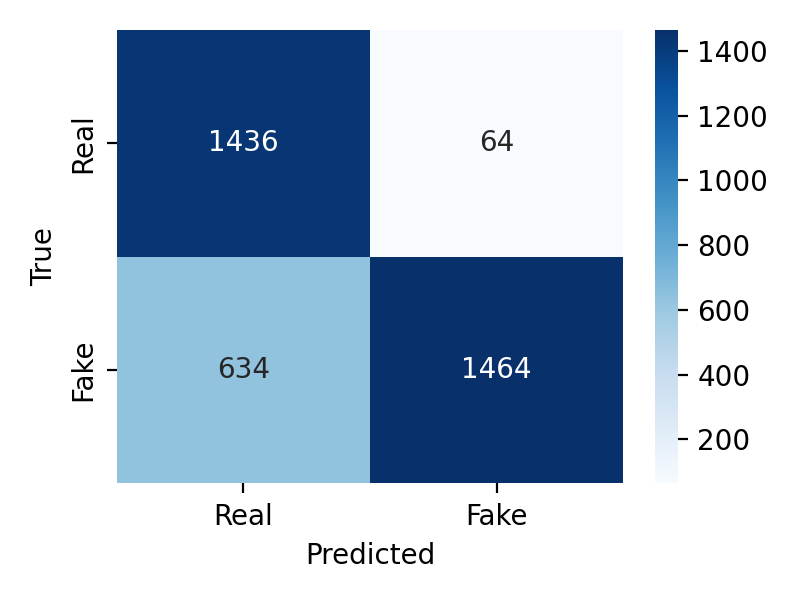

**R1 - roc_curve.png**

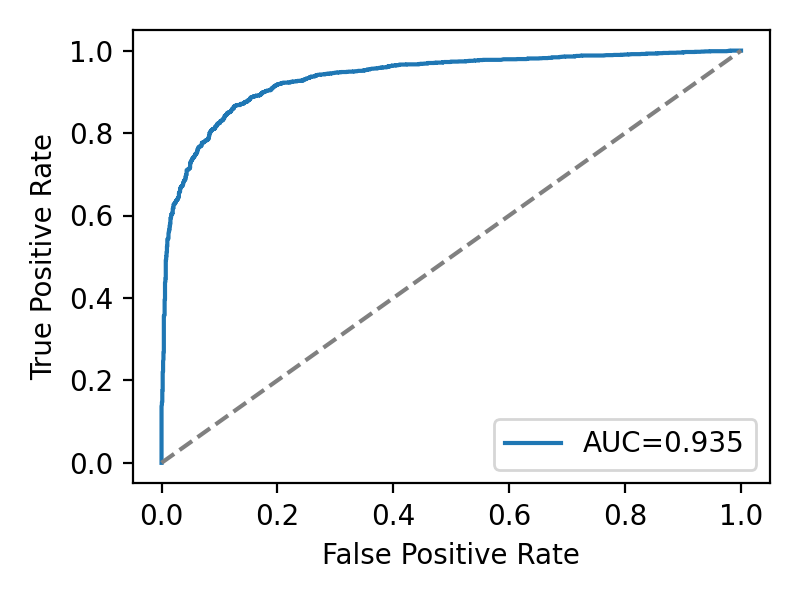

**R1 - history_loss.png**

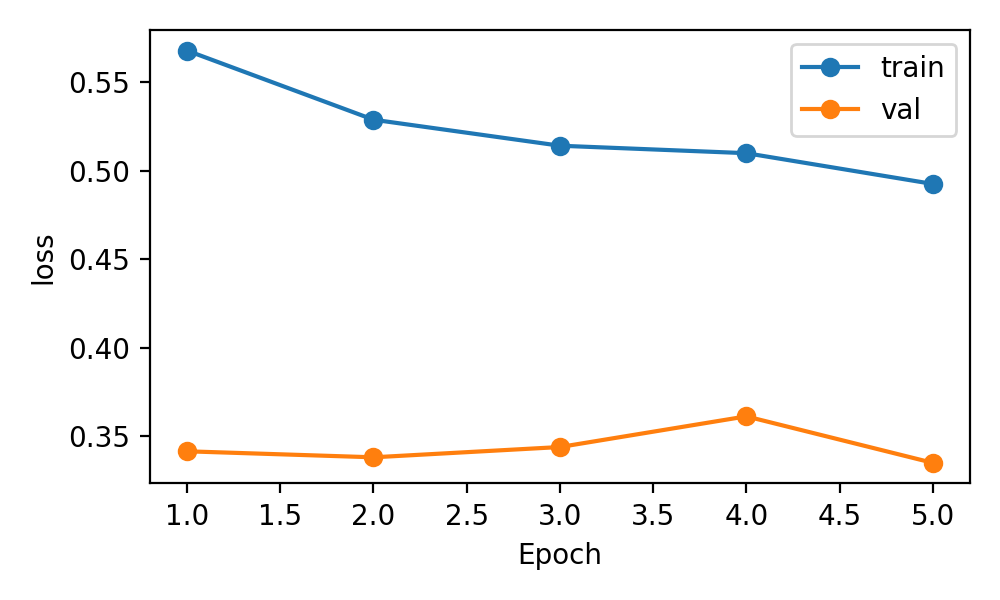

**R1 - history_auc.png**

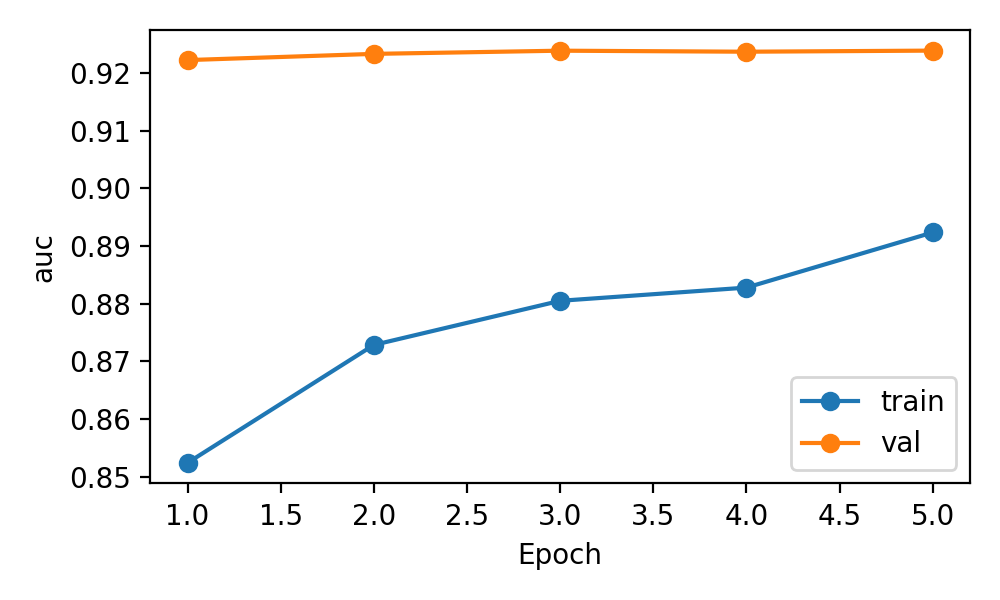

**R1 - history_acc.png**

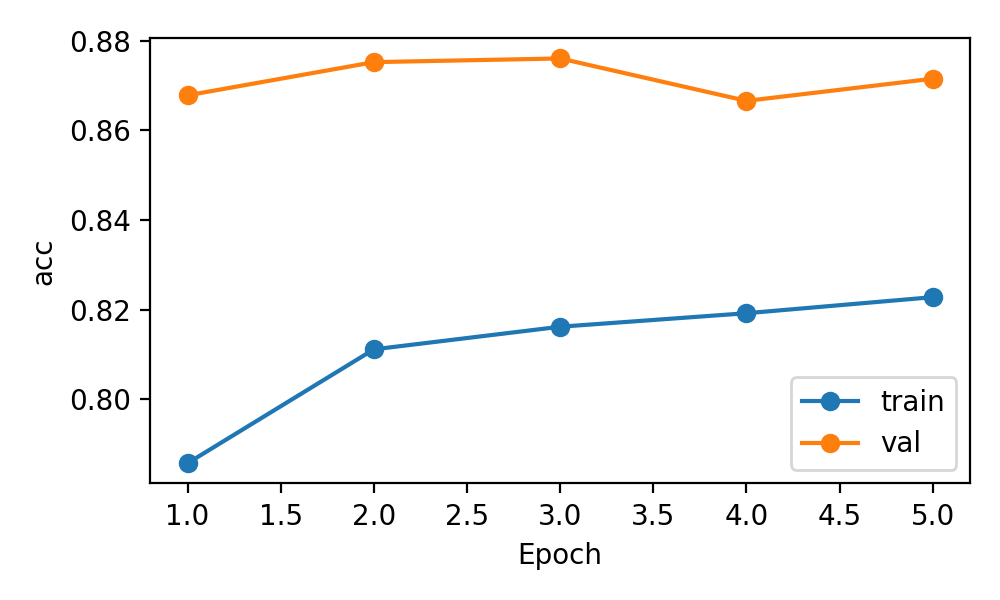

**R1 - history_f1.png**

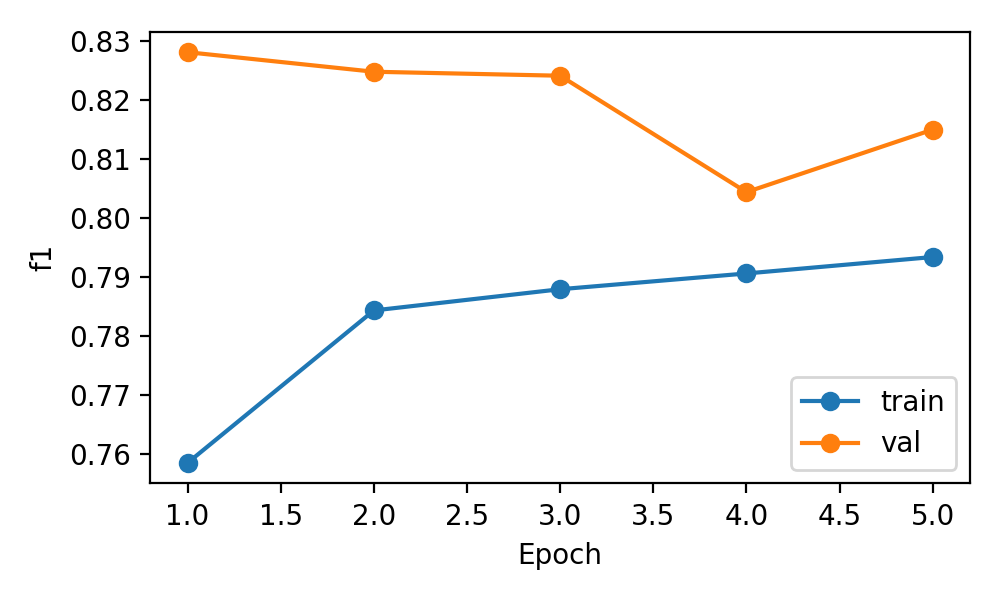

结果 Markdown 已更新：`docs/ood_split_experiment_results.md`

{'编号': 'R1',
 'Method': 'frequency_wave',
 'Spatial': '',
 'Temporal': '',
 'Frequency': '✓',
 'Fusion': '-',
 'Epochs': 5,
 'Best Val Epoch': 5,
 'Train Loss': 0.49258435013741414,
 'Train ACC': 0.8227817159618676,
 'Train AUC': 0.8923504781772371,
 'Val Loss': 0.3350906215022257,
 'Val ACC': 0.8715520790448744,
 'Val AUC': 0.9238453534266237,
 'Val F1': 0.8149466192170819,
 'Test ACC': 0.8060033351862146,
 'Test AUC': 0.9353740069907849,
 'Test F1': 0.8075013789299503,
 'Test Precision': 0.9581151832460733,
 'Test Recall': 0.6978074356530028,
 'TN': 1436,
 'FP': 64,
 'FN': 634,
 'TP': 1464,
 'Seconds Eval': 1226.4436678886414,
 'Num Test Samples': 3598,
 'Run Dir': 'runs\\ood_frequency_wave',
 'Output Dir': 'outputs\\ood_frequency_wave',
 'Figure Dir': 'outputs\\figures\\ood_frequency_wave'}

In [8]:
# OOD-R1: frequency_wave
R1_summary = run_experiment("R1", force=False, poll_seconds=60, live_output=True)
R1_summary


### R2. Spatial only: `spatial_dino`

运行下面 cell 开始 R2。默认 `force=False`，如需删除旧结果并重跑，改成 `force=True`。


========== R2: spatial_dino ==========
run_dir = runs/ood_spatial_dino
out_dir = outputs/ood_spatial_dino
fig_dir = outputs/figures/ood_spatial_dino

[start] R2 train
[log] logs/r2_spatial_dino_train.log
[cmd] D:\VsCode Program\Python\content_security\final_project\.venv\Scripts\python.exe -m src.train --model spatial_dino --train-csv data\GenVideo-Val\splits\ood_train.csv --val-csv data\GenVideo-Val\splits\ood_val.csv --epochs 5 --batch-size 1 --num-frames 8 --image-size 112 --foundation-backbone dinov2_vits14 --wavelet-aug-prob 0.1 --branch-dropout 0.1 --aux-loss-weight 0.2 --amp --out-dir runs\ood_spatial_dino


```text
R2 train done, elapsed=238.4 min
eval: 100%|█████████▉| 2428/2429 [06:47<00:00, 10.26it/s]
```

[device] cuda
[model] spatial_dino
Using cache found in C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
D:\VsCode Program\Python\content_security\final_project\src\models\fusion\branch_token_transformer.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
[par

```text
R2 evaluate done, elapsed=10.6 min
predict: 100%|██████████| 3598/3598 [10:03<00:00,  5.96it/s]
```

Using cache found in C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
D:\VsCode Program\Python\content_security\final_project\src\models\fusion\branch_token_transformer.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
{'acc': 0.8857698721511951, 'auc': 0.96

```text
R2 visualize done, elapsed=0.1 min

```

[done] figures in outputs\figures\ood_spatial_dino

[done] R2 visualize, elapsed=0.1 min
[write] docs/ood_split_experiment_results.md


,编号,Method,Spatial,Temporal,Frequency,Fusion,Epochs,Best Val Epoch,Val ACC,Val AUC,Val F1,Test ACC,Test AUC,Test F1,Test Precision,Test Recall
0,R1,frequency_wave,,,✓,-,5,5,0.871552,0.923845,0.814947,0.806003,0.935374,0.807501,0.958115,0.697807
1,R2,spatial_dino,✓,,,-,5,4,0.970358,0.991943,0.960526,0.885770,0.965718,0.892267,0.991264,0.811249
2,R3,temporal_d3_restrav,,✓,,-,5,5,0.914368,0.973751,0.879630,0.812952,0.954971,0.813418,0.972167,0.699237
3,R4,spatial_frequency_new,✓,,✓,Transformer,5,3,0.976122,0.996302,0.968341,0.874931,0.963604,0.880510,0.994005,0.790276
4,R5,spatial_temporal_new,✓,✓,,Transformer,5,3,0.978180,0.997536,0.971022,0.887715,0.979481,0.893852,0.995902,0.810772
5,R6,stf3_new_concat,✓,✓,✓,Gated Concat,5,5,0.976945,0.998347,0.969231,0.881879,0.974404,0.887892,0.994093,0.802193
6,R7,stf3_new,✓,✓,✓,Branch-token Transformer,5,3,0.974475,0.994897,0.966083,0.916064,0.965099,0.923506,0.985405,0.868923


**R2 - confusion_matrix.png**

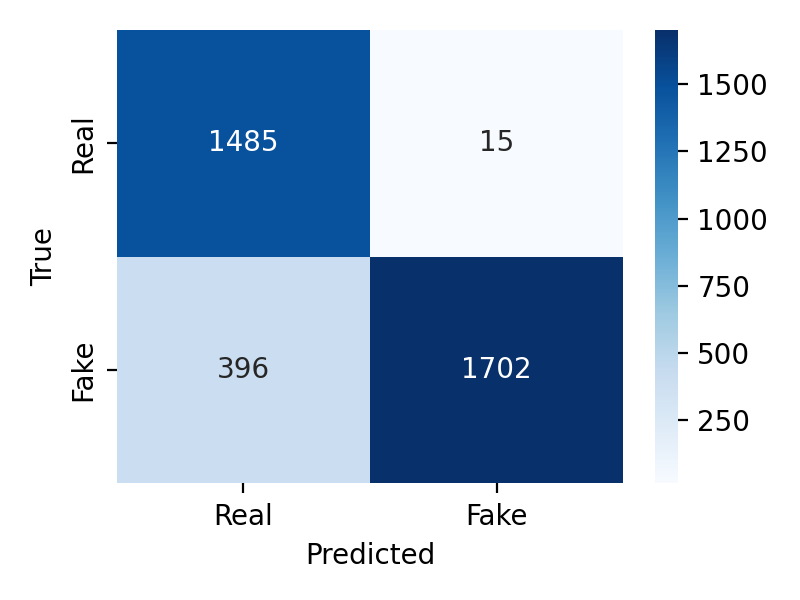

**R2 - roc_curve.png**

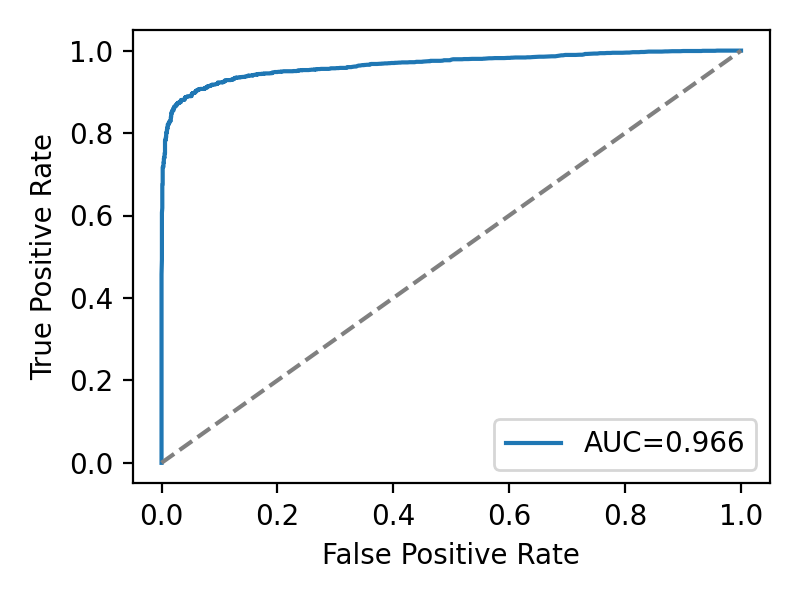

**R2 - history_loss.png**

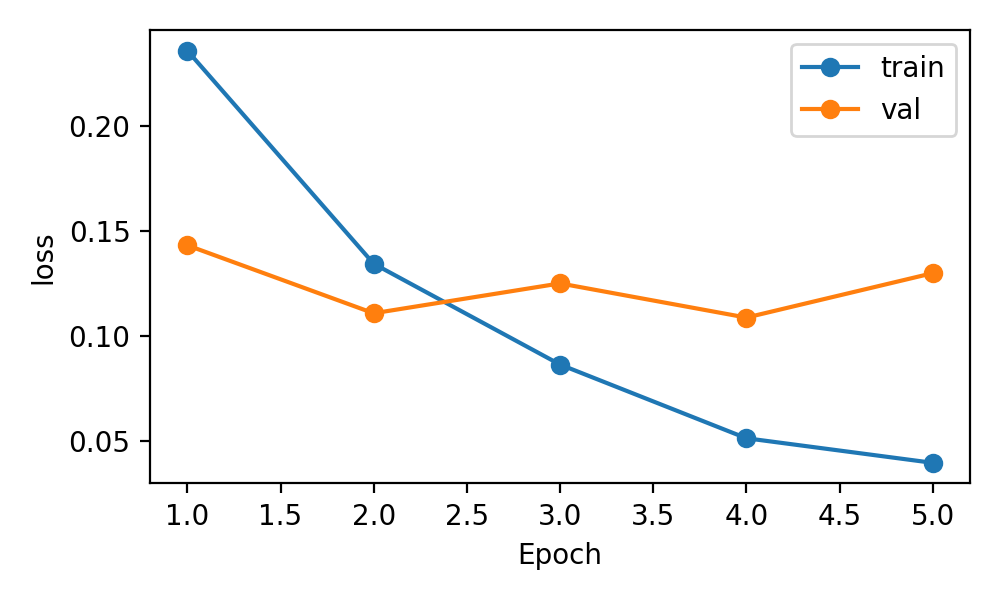

**R2 - history_auc.png**

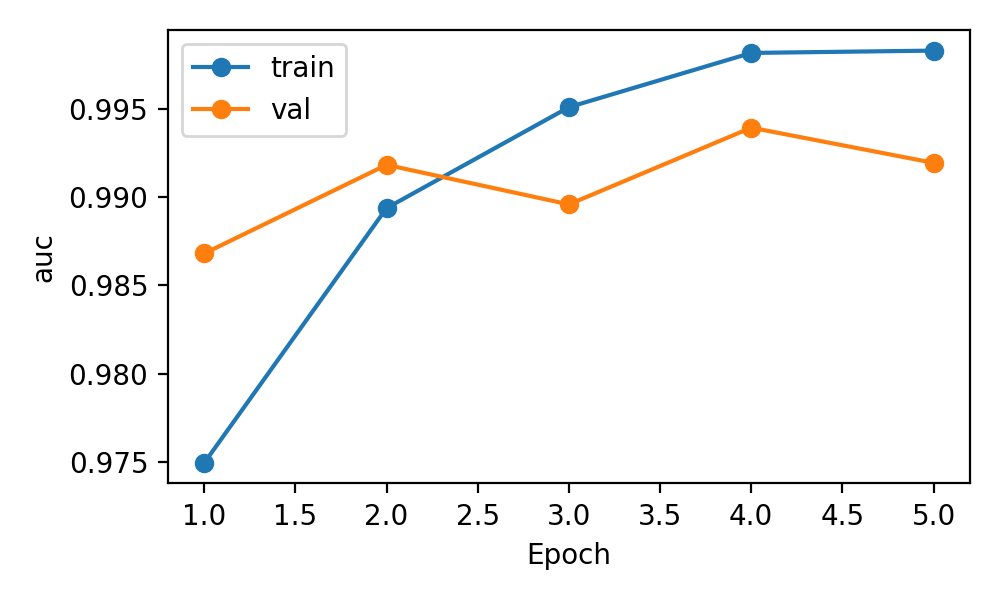

**R2 - history_acc.png**

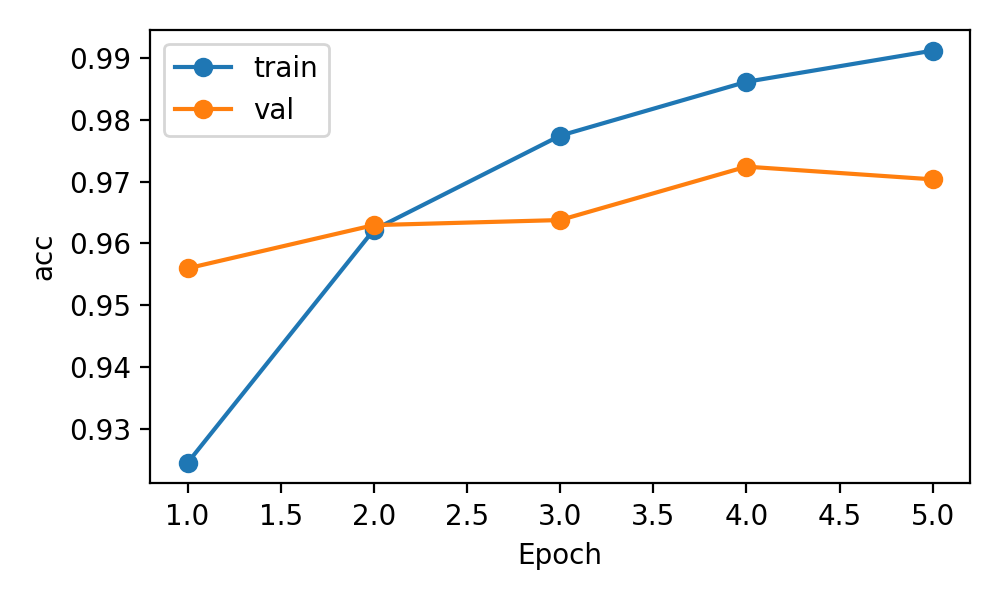

**R2 - history_f1.png**

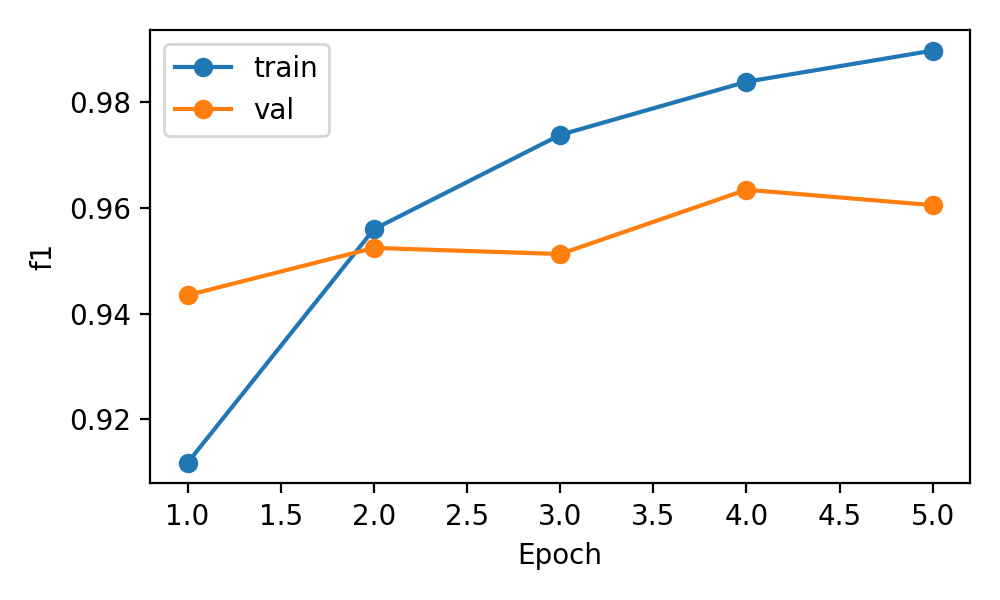

结果 Markdown 已更新：`docs/ood_split_experiment_results.md`

{'编号': 'R2',
 'Method': 'spatial_dino',
 'Spatial': '✓',
 'Temporal': '',
 'Frequency': '',
 'Fusion': '-',
 'Epochs': 5,
 'Best Val Epoch': 4,
 'Train Loss': 0.03974349032503708,
 'Train ACC': 0.99120019555121,
 'Train AUC': 0.9983061688927419,
 'Val Loss': 0.12999029618911462,
 'Val ACC': 0.9703581720872787,
 'Val AUC': 0.9919433082167205,
 'Val F1': 0.9605263157894737,
 'Test ACC': 0.8857698721511951,
 'Test AUC': 0.9657175087384812,
 'Test F1': 0.892267365661861,
 'Test Precision': 0.9912638322655795,
 'Test Recall': 0.8112488083889419,
 'TN': 1485,
 'FP': 15,
 'FN': 396,
 'TP': 1702,
 'Seconds Eval': 603.6047220230103,
 'Num Test Samples': 3598,
 'Run Dir': 'runs\\ood_spatial_dino',
 'Output Dir': 'outputs\\ood_spatial_dino',
 'Figure Dir': 'outputs\\figures\\ood_spatial_dino'}

In [7]:
# OOD-R2: spatial_dino
R2_summary = run_experiment("R2", force=False, poll_seconds=60, live_output=True)
R2_summary


### R3. Temporal only: `temporal_d3_restrav`

运行下面 cell 开始 R3。默认 `force=False`，如需删除旧结果并重跑，改成 `force=True`。


========== R3: temporal_d3_restrav ==========
run_dir = runs/ood_temporal_d3_restrav
out_dir = outputs/ood_temporal_d3_restrav
fig_dir = outputs/figures/ood_temporal_d3_restrav

[start] R3 train
[log] logs/r3_temporal_d3_restrav_train.log
[cmd] D:\VsCode Program\Python\content_security\final_project\.venv\Scripts\python.exe -m src.train --model temporal_d3_restrav --train-csv data\GenVideo-Val\splits\ood_train.csv --val-csv data\GenVideo-Val\splits\ood_val.csv --epochs 5 --batch-size 1 --num-frames 8 --image-size 112 --foundation-backbone dinov2_vits14 --wavelet-aug-prob 0.1 --branch-dropout 0.1 --aux-loss-weight 0.2 --amp --out-dir runs\ood_temporal_d3_restrav


```text
R3 train done, elapsed=223.9 min
eval: 100%|█████████▉| 2428/2429 [06:45<00:00, 10.27it/s]
```

[device] cuda
[model] temporal_d3_restrav
Using cache found in C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
D:\VsCode Program\Python\content_security\final_project\src\models\fusion\branch_token_transformer.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layer

```text
R3 evaluate done, elapsed=10.5 min
predict: 100%|██████████| 3598/3598 [09:58<00:00,  6.01it/s]
```

Using cache found in C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
D:\VsCode Program\Python\content_security\final_project\src\models\fusion\branch_token_transformer.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
{'acc': 0.8129516397998888, 'auc': 0.95

```text
R3 visualize done, elapsed=0.1 min

```

[done] figures in outputs\figures\ood_temporal_d3_restrav

[done] R3 visualize, elapsed=0.1 min
[write] docs/ood_split_experiment_results.md


,编号,Method,Spatial,Temporal,Frequency,Fusion,Epochs,Best Val Epoch,Val ACC,Val AUC,Val F1,Test ACC,Test AUC,Test F1,Test Precision,Test Recall
0,R3,temporal_d3_restrav,,✓,,-,5,5,0.914368,0.973751,0.879630,0.812952,0.954971,0.813418,0.972167,0.699237
1,R4,spatial_frequency_new,✓,,✓,Transformer,5,3,0.976122,0.996302,0.968341,0.874931,0.963604,0.880510,0.994005,0.790276
2,R5,spatial_temporal_new,✓,✓,,Transformer,5,3,0.978180,0.997536,0.971022,0.887715,0.979481,0.893852,0.995902,0.810772
3,R6,stf3_new_concat,✓,✓,✓,Gated Concat,5,5,0.976945,0.998347,0.969231,0.881879,0.974404,0.887892,0.994093,0.802193
4,R7,stf3_new,✓,✓,✓,Branch-token Transformer,5,3,0.974475,0.994897,0.966083,0.916064,0.965099,0.923506,0.985405,0.868923


**R3 - confusion_matrix.png**

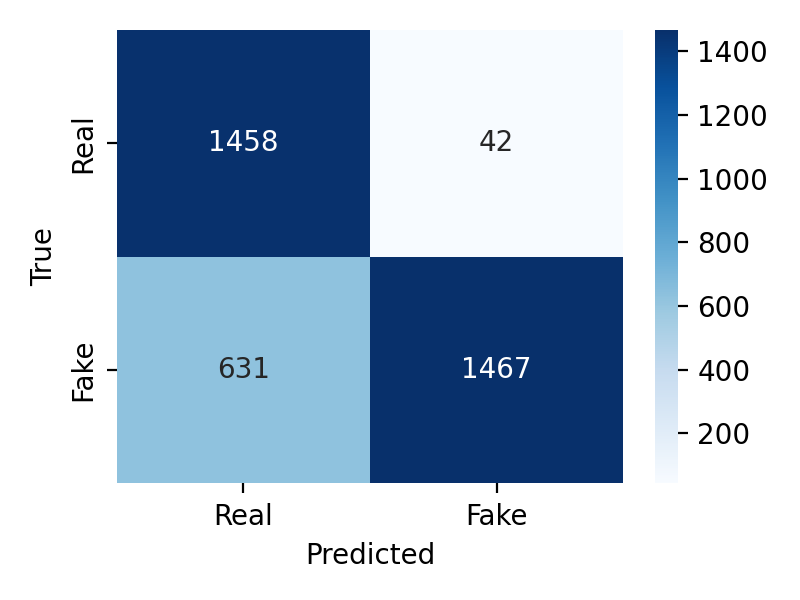

**R3 - roc_curve.png**

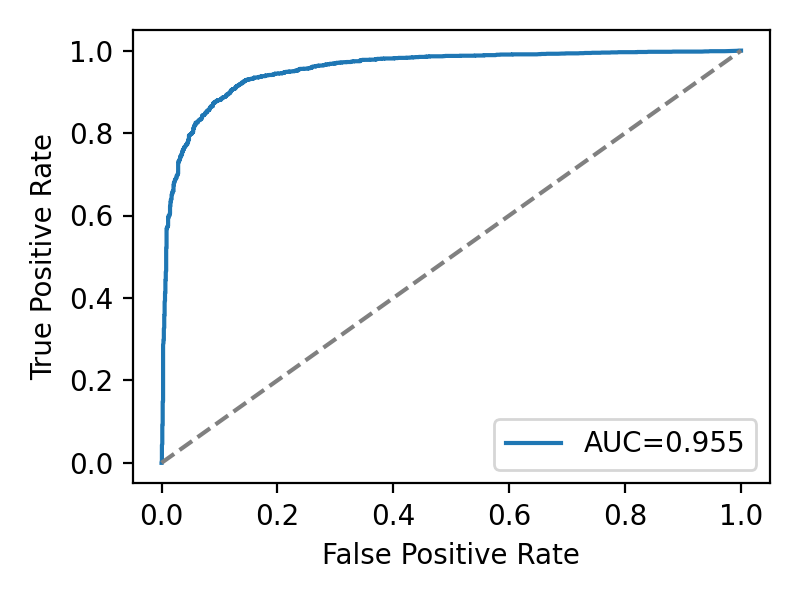

**R3 - history_loss.png**

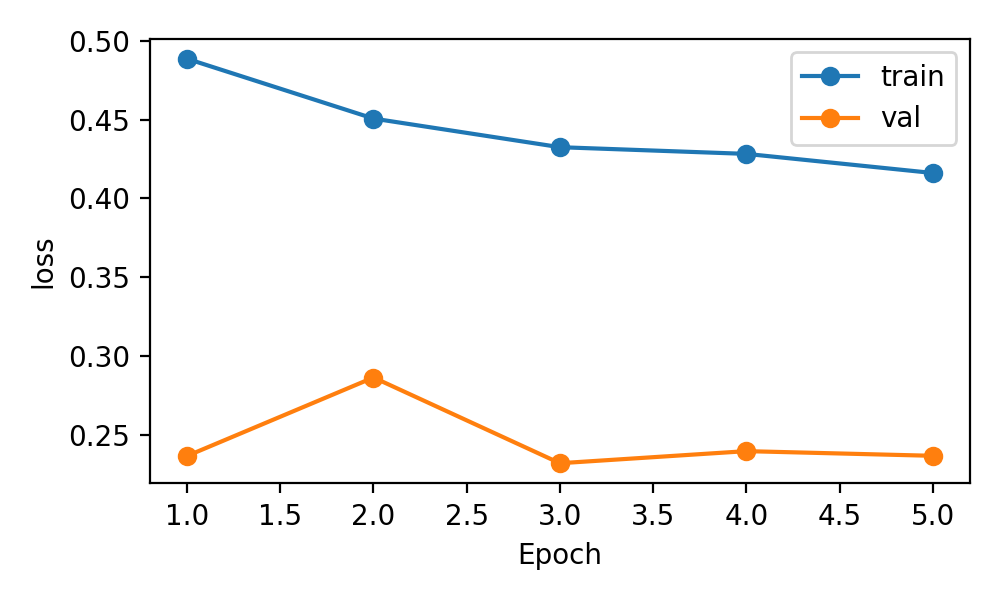

**R3 - history_auc.png**

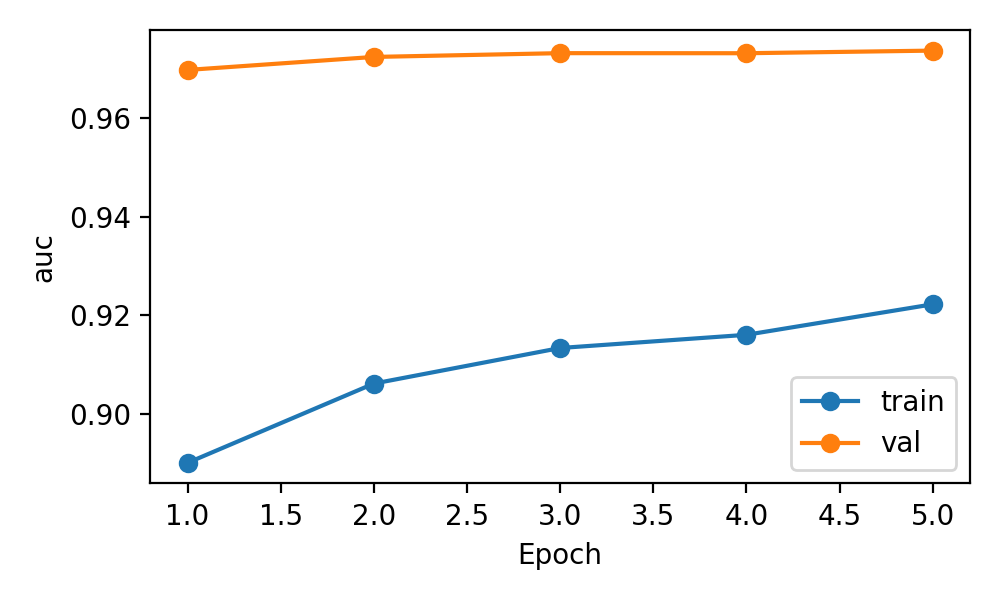

**R3 - history_acc.png**

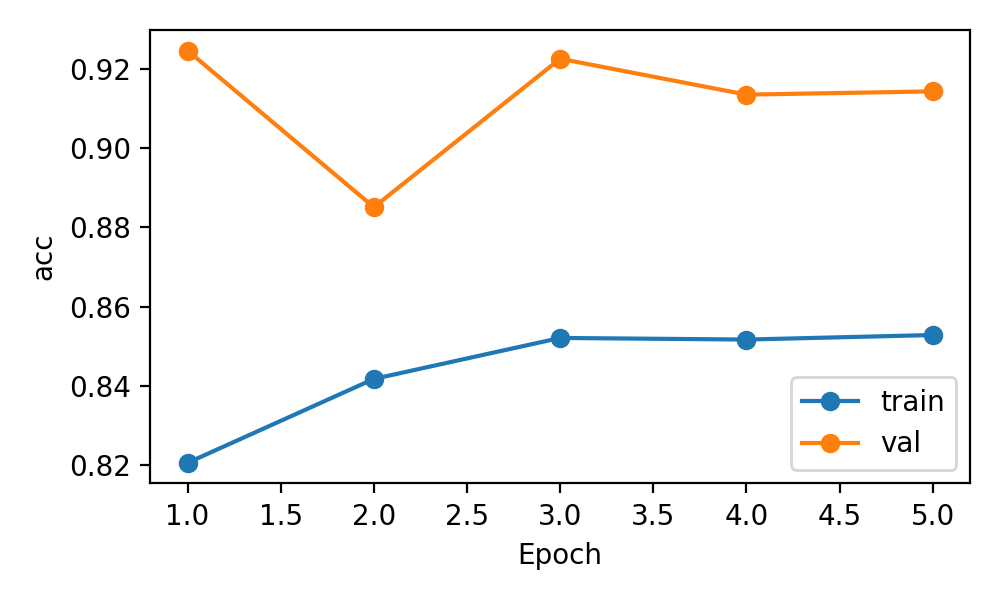

**R3 - history_f1.png**

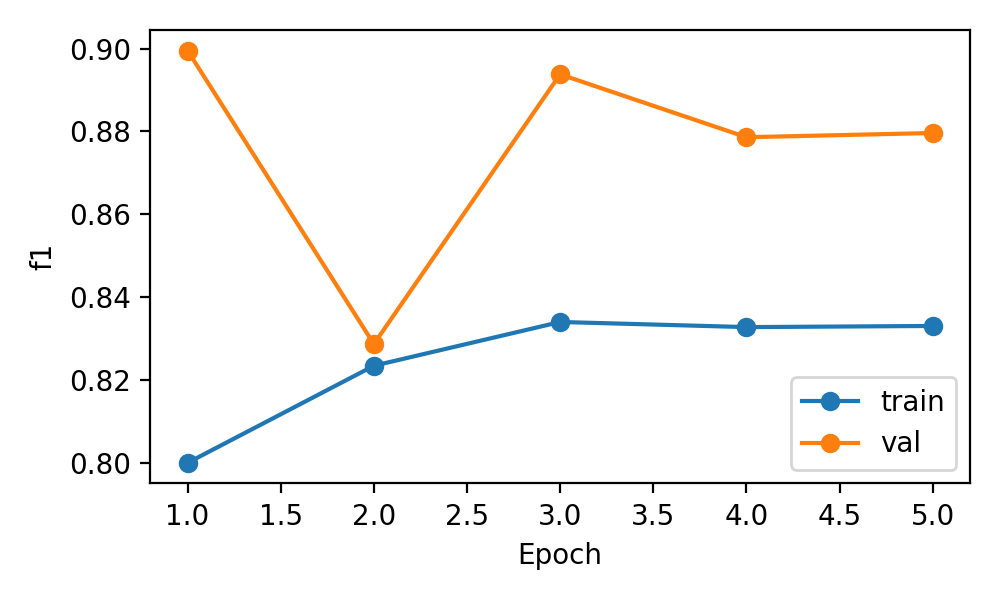

结果 Markdown 已更新：`docs/ood_split_experiment_results.md`

{'编号': 'R3',
 'Method': 'temporal_d3_restrav',
 'Spatial': '',
 'Temporal': '✓',
 'Frequency': '',
 'Fusion': '-',
 'Epochs': 5,
 'Best Val Epoch': 5,
 'Train Loss': 0.41613274353767976,
 'Train ACC': 0.8528477144952334,
 'Train AUC': 0.922266776841592,
 'Val Loss': 0.23654579674574316,
 'Val ACC': 0.914368052696583,
 'Val AUC': 0.9737506279153211,
 'Val F1': 0.8796296296296297,
 'Test ACC': 0.8129516397998888,
 'Test AUC': 0.9549714013346045,
 'Test F1': 0.813418353202107,
 'Test Precision': 0.9721669980119284,
 'Test Recall': 0.6992373689227837,
 'TN': 1458,
 'FP': 42,
 'FN': 631,
 'TP': 1467,
 'Seconds Eval': 598.5584411621094,
 'Num Test Samples': 3598,
 'Run Dir': 'runs\\ood_temporal_d3_restrav',
 'Output Dir': 'outputs\\ood_temporal_d3_restrav',
 'Figure Dir': 'outputs\\figures\\ood_temporal_d3_restrav'}

In [7]:
# OOD-R3: temporal_d3_restrav
R3_summary = run_experiment("R3", force=False, poll_seconds=60, live_output=True)
R3_summary


### R4. Spatial + Frequency: `spatial_frequency_new`

运行下面 cell 开始 R4。默认 `force=False`，如需删除旧结果并重跑，改成 `force=True`。


========== R4: spatial_frequency_new ==========
run_dir = runs/ood_spatial_frequency_new
out_dir = outputs/ood_spatial_frequency_new
fig_dir = outputs/figures/ood_spatial_frequency_new

[start] R4 train
[log] logs/r4_spatial_frequency_new_train.log
[cmd] D:\VsCode Program\Python\content_security\final_project\.venv\Scripts\python.exe -m src.train --model spatial_frequency_new --train-csv data\GenVideo-Val\splits\ood_train.csv --val-csv data\GenVideo-Val\splits\ood_val.csv --epochs 5 --batch-size 1 --num-frames 8 --image-size 112 --foundation-backbone dinov2_vits14 --wavelet-aug-prob 0.1 --branch-dropout 0.1 --aux-loss-weight 0.2 --amp --out-dir runs\ood_spatial_frequency_new


```text
R4 train done, elapsed=223.4 min
eval: 100%|█████████▉| 2428/2429 [06:50<00:00,  9.36it/s]
```

[device] cuda
[model] spatial_frequency_new
Using cache found in C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
D:\VsCode Program\Python\content_security\final_project\src\models\fusion\branch_token_transformer.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_lay

```text
R4 evaluate done, elapsed=10.3 min
predict: 100%|██████████| 3598/3598 [10:02<00:00,  5.97it/s]
```

Using cache found in C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
D:\VsCode Program\Python\content_security\final_project\src\models\fusion\branch_token_transformer.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
{'acc': 0.8749305169538633, 'auc': 0.96

```text
R4 visualize done, elapsed=0.1 min

```

[done] figures in outputs\figures\ood_spatial_frequency_new

[done] R4 visualize, elapsed=0.1 min
[write] docs/ood_split_experiment_results.md


,编号,Method,Spatial,Temporal,Frequency,Fusion,Epochs,Best Val Epoch,Val ACC,Val AUC,Val F1,Test ACC,Test AUC,Test F1,Test Precision,Test Recall
0,R4,spatial_frequency_new,✓,,✓,Transformer,5,3,0.976122,0.996302,0.968341,0.874931,0.963604,0.880510,0.994005,0.790276
1,R5,spatial_temporal_new,✓,✓,,Transformer,5,3,0.978180,0.997536,0.971022,0.887715,0.979481,0.893852,0.995902,0.810772
2,R7,stf3_new,✓,✓,✓,Branch-token Transformer,5,3,0.974475,0.994897,0.966083,0.916064,0.965099,0.923506,0.985405,0.868923


**R4 - confusion_matrix.png**

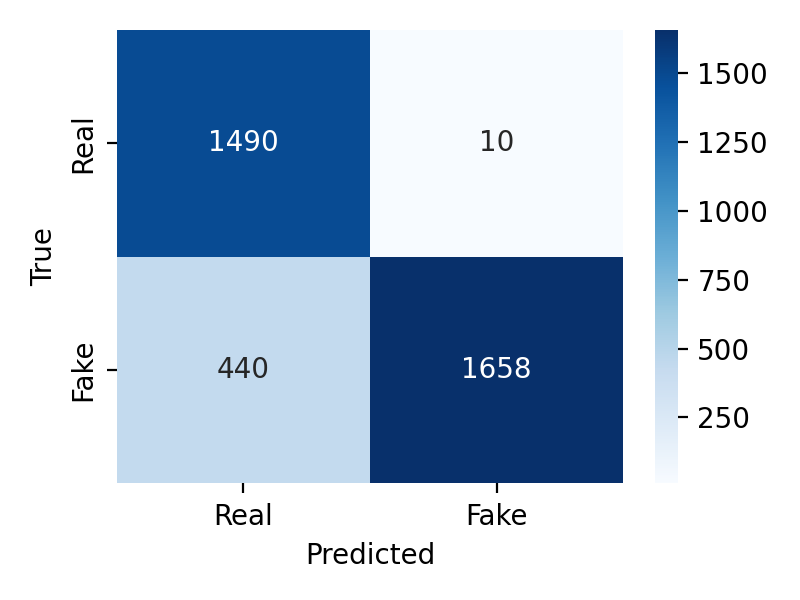

**R4 - roc_curve.png**

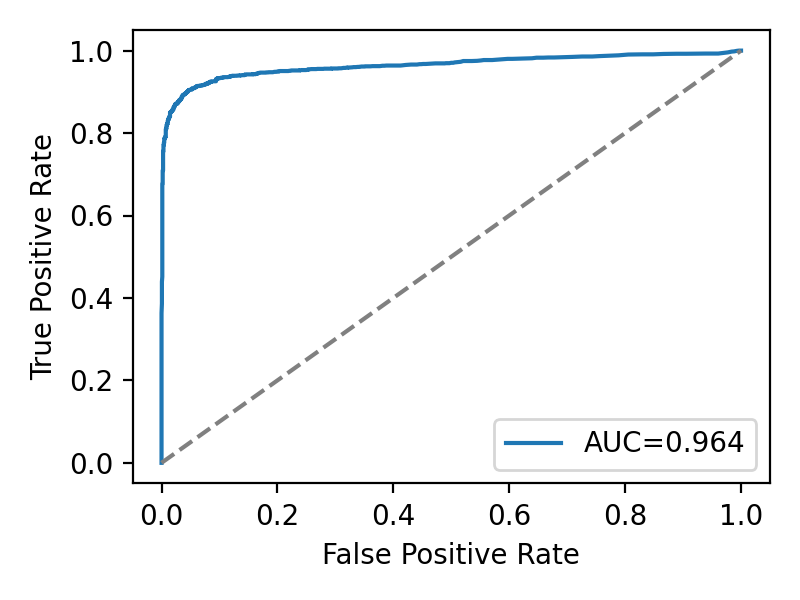

**R4 - history_loss.png**

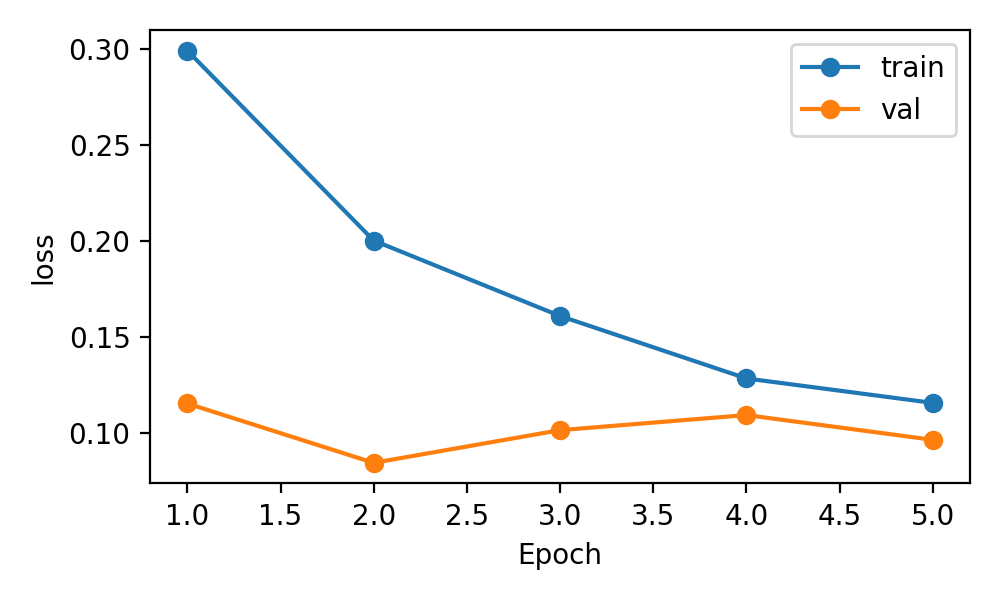

**R4 - history_auc.png**

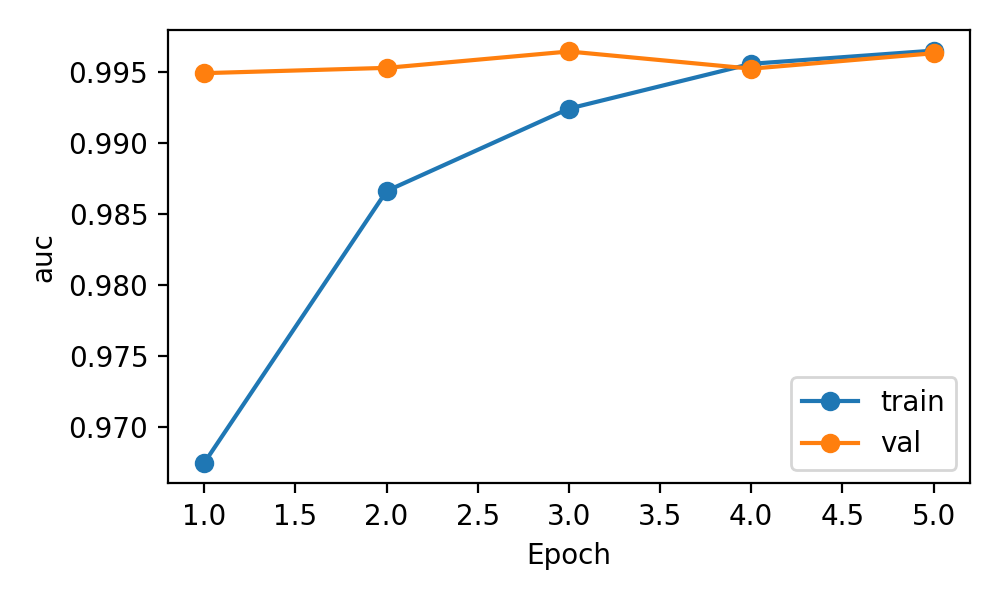

**R4 - history_acc.png**

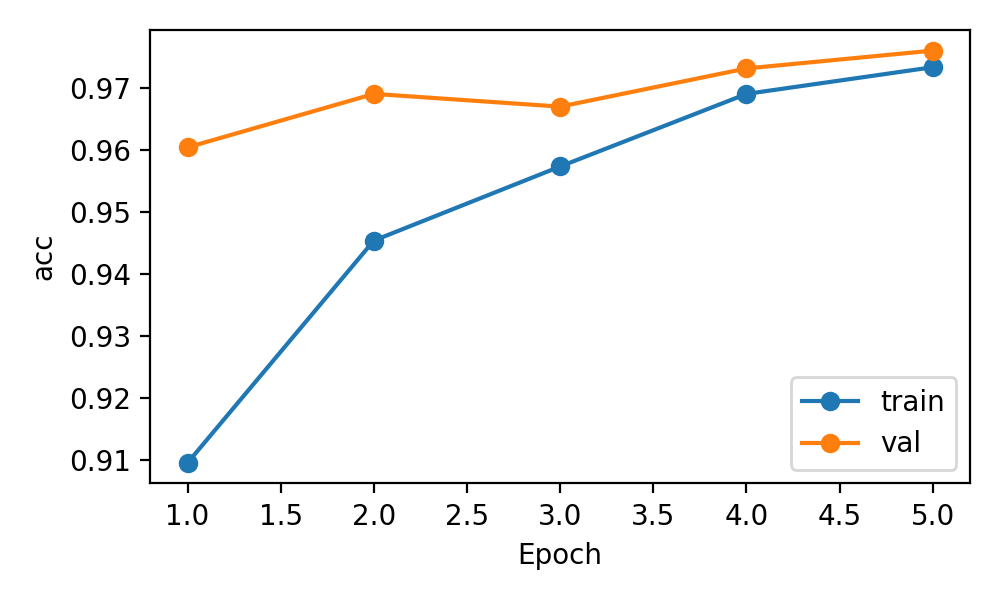

**R4 - history_f1.png**

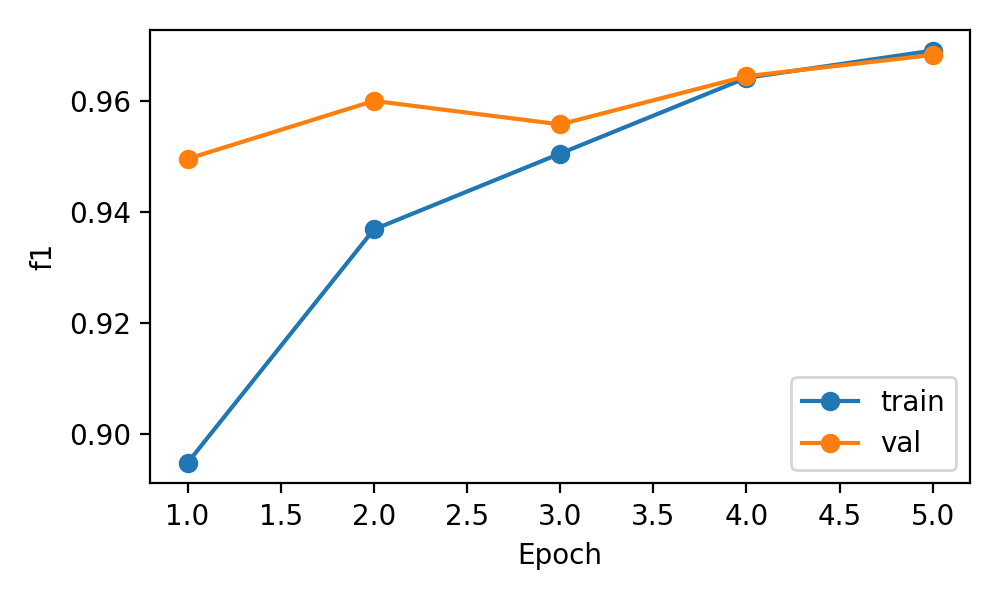

结果 Markdown 已更新：`docs/ood_split_experiment_results.md`

{'编号': 'R4',
 'Method': 'spatial_frequency_new',
 'Spatial': '✓',
 'Temporal': '',
 'Frequency': '✓',
 'Fusion': 'Transformer',
 'Epochs': 5,
 'Best Val Epoch': 3,
 'Train Loss': 0.1156150298682548,
 'Train ACC': 0.9734376273119857,
 'Train AUC': 0.9964876595052964,
 'Val Loss': 0.09638061323201229,
 'Val ACC': 0.9761218608480856,
 'Val AUC': 0.996302475780409,
 'Val F1': 0.9683406113537117,
 'Test ACC': 0.8749305169538633,
 'Test AUC': 0.9636039084842708,
 'Test F1': 0.880509824747743,
 'Test Precision': 0.9940047961630696,
 'Test Recall': 0.7902764537654909,
 'TN': 1490,
 'FP': 10,
 'FN': 440,
 'TP': 1658,
 'Seconds Eval': 602.5514080524445,
 'Num Test Samples': 3598,
 'Run Dir': 'runs\\ood_spatial_frequency_new',
 'Output Dir': 'outputs\\ood_spatial_frequency_new',
 'Figure Dir': 'outputs\\figures\\ood_spatial_frequency_new'}

In [8]:
# OOD-R4: spatial_frequency_new
R4_summary = run_experiment("R4", force=False, poll_seconds=60, live_output=True)
R4_summary


### R5. Spatial + Temporal: `spatial_temporal_new`

运行下面 cell 开始 R5。默认 `force=False`，如需删除旧结果并重跑，改成 `force=True`。


========== R5: spatial_temporal_new ==========
run_dir = runs/ood_spatial_temporal_new
out_dir = outputs/ood_spatial_temporal_new
fig_dir = outputs/figures/ood_spatial_temporal_new

[start] R5 train
[log] logs/r5_spatial_temporal_new_train.log
[cmd] D:\VsCode Program\Python\content_security\final_project\.venv\Scripts\python.exe -m src.train --model spatial_temporal_new --train-csv data\GenVideo-Val\splits\ood_train.csv --val-csv data\GenVideo-Val\splits\ood_val.csv --epochs 5 --batch-size 1 --num-frames 8 --image-size 112 --foundation-backbone dinov2_vits14 --wavelet-aug-prob 0.1 --branch-dropout 0.1 --aux-loss-weight 0.2 --amp --out-dir runs\ood_spatial_temporal_new


```text
R5 train done, elapsed=239.6 min
eval: 100%|█████████▉| 2428/2429 [07:23<00:00,  8.89it/s]
```

[device] cuda
[model] spatial_temporal_new
Using cache found in C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
D:\VsCode Program\Python\content_security\final_project\src\models\fusion\branch_token_transformer.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_laye

```text
R5 evaluate done, elapsed=10.8 min
predict: 100%|██████████| 3598/3598 [10:36<00:00,  5.66it/s]
```

Using cache found in C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
D:\VsCode Program\Python\content_security\final_project\src\models\fusion\branch_token_transformer.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
{'acc': 0.8877153974430239, 'auc': 0.97

```text
R5 visualize done, elapsed=0.1 min

```

[done] figures in outputs\figures\ood_spatial_temporal_new

[done] R5 visualize, elapsed=0.1 min
[write] docs/ood_split_experiment_results.md


,编号,Method,Spatial,Temporal,Frequency,Fusion,Epochs,Best Val Epoch,Val ACC,Val AUC,Val F1,Test ACC,Test AUC,Test F1,Test Precision,Test Recall
0,R5,spatial_temporal_new,✓,✓,,Transformer,5,3,0.97818,0.997536,0.971022,0.887715,0.979481,0.893852,0.995902,0.810772


**R5 - confusion_matrix.png**

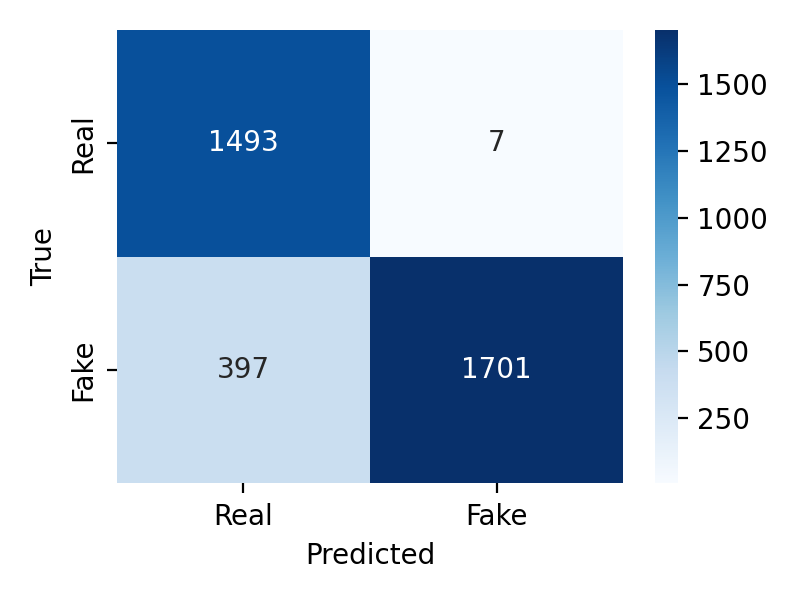

**R5 - roc_curve.png**

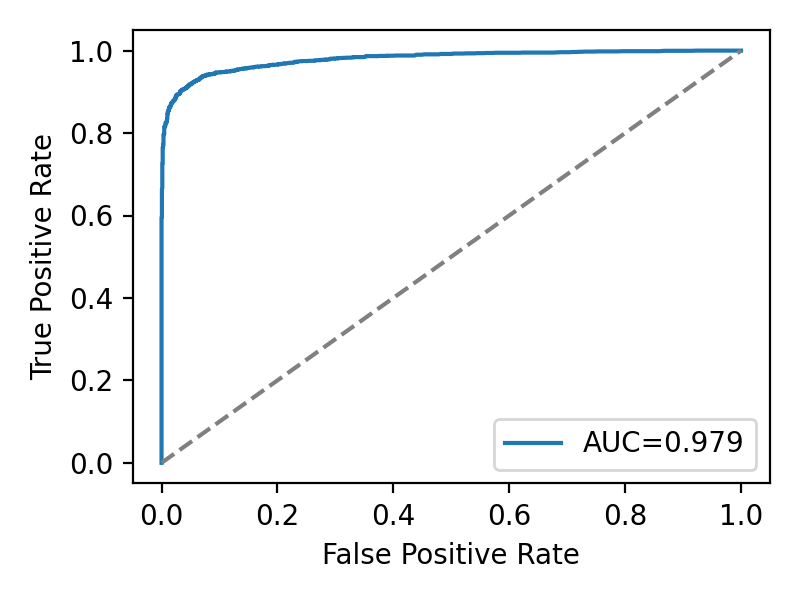

**R5 - history_loss.png**

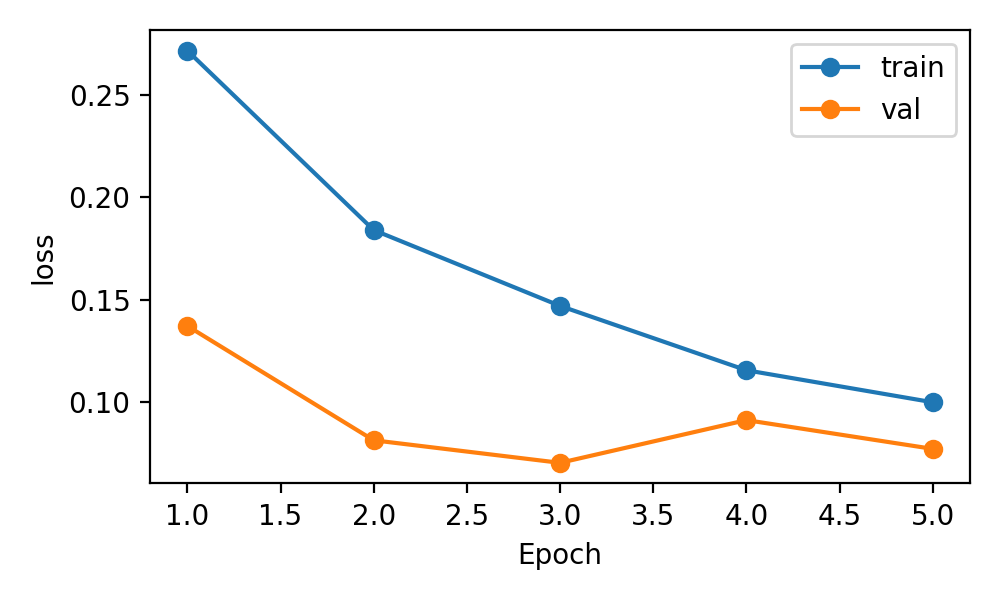

**R5 - history_auc.png**

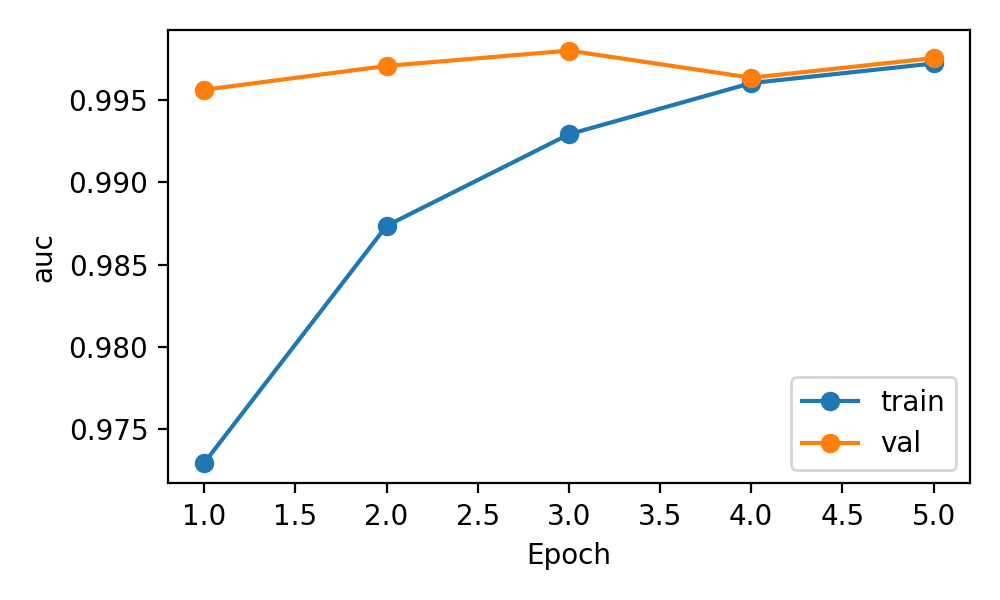

**R5 - history_acc.png**

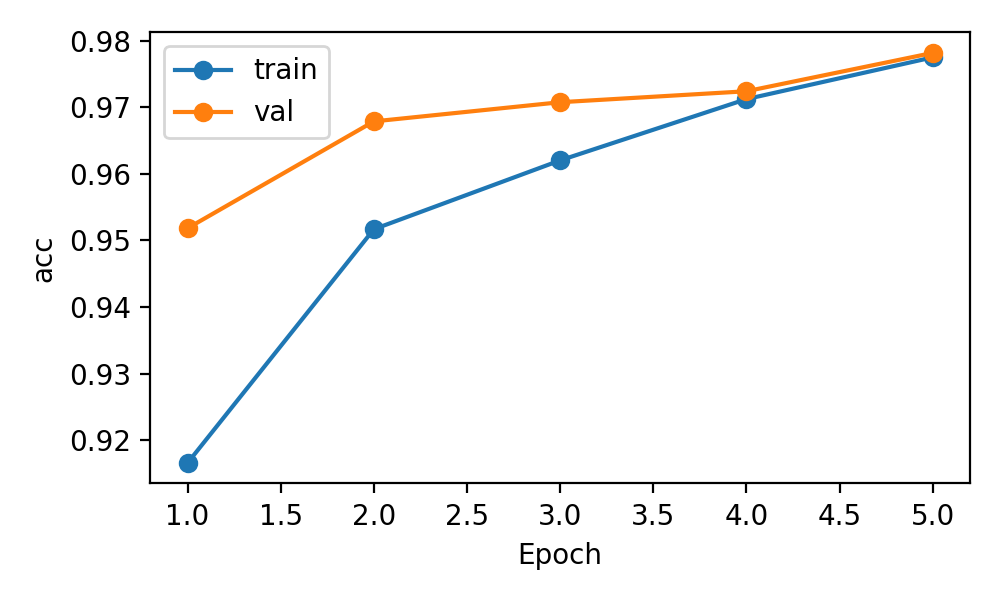

**R5 - history_f1.png**

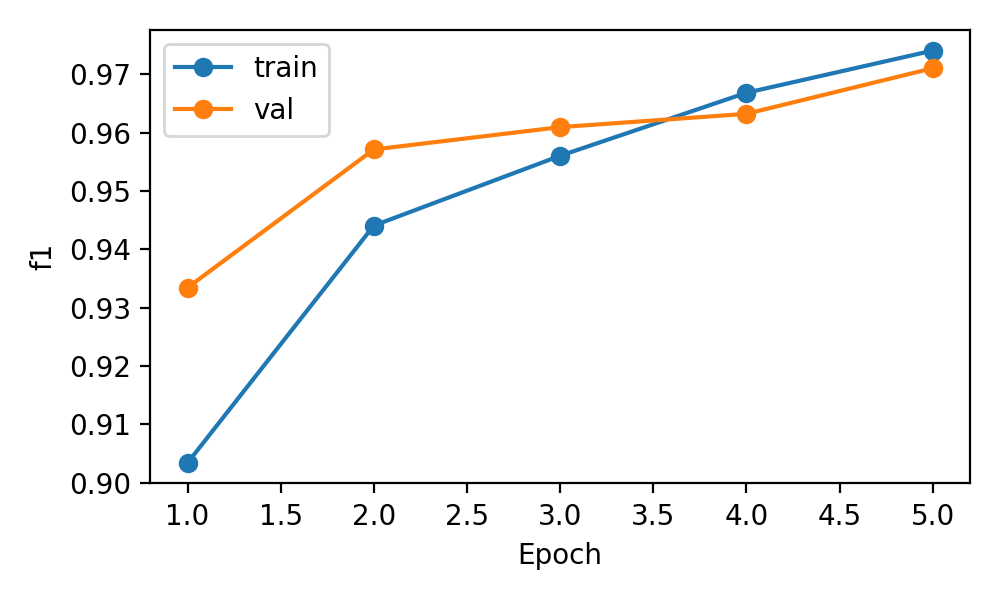

结果 Markdown 已更新：`docs/ood_split_experiment_results.md`

{'编号': 'R5',
 'Method': 'spatial_temporal_new',
 'Spatial': '✓',
 'Temporal': '✓',
 'Frequency': '',
 'Fusion': 'Transformer',
 'Epochs': 5,
 'Best Val Epoch': 3,
 'Train Loss': 0.09997212181447562,
 'Train ACC': 0.9775116108530921,
 'Train AUC': 0.9972104928070223,
 'Val Loss': 0.0772402870551997,
 'Val ACC': 0.9781803211198024,
 'Val AUC': 0.9975360602798709,
 'Val F1': 0.9710224166211044,
 'Test ACC': 0.8877153974430239,
 'Test AUC': 0.9794814108674927,
 'Test F1': 0.8938518129269575,
 'Test Precision': 0.9959016393442623,
 'Test Recall': 0.8107721639656816,
 'TN': 1493,
 'FP': 7,
 'FN': 397,
 'TP': 1701,
 'Seconds Eval': 636.0285022258759,
 'Num Test Samples': 3598,
 'Run Dir': 'runs\\ood_spatial_temporal_new',
 'Output Dir': 'outputs\\ood_spatial_temporal_new',
 'Figure Dir': 'outputs\\figures\\ood_spatial_temporal_new'}

In [7]:
# OOD-R5: spatial_temporal_new
R5_summary = run_experiment("R5", force=False, poll_seconds=60, live_output=True)
R5_summary


### R6. STF3-New Concat Fusion: `stf3_new_concat`

运行下面 cell 开始 R6。默认 `force=False`，如需删除旧结果并重跑，改成 `force=True`。


========== R6: stf3_new_concat ==========
run_dir = runs/ood_stf3_new_concat
out_dir = outputs/ood_stf3_new_concat
fig_dir = outputs/figures/ood_stf3_new_concat

[start] R6 train
[log] logs/r6_stf3_new_concat_train.log
[cmd] D:\VsCode Program\Python\content_security\final_project\.venv\Scripts\python.exe -m src.train --model stf3_new_concat --train-csv data\GenVideo-Val\splits\ood_train.csv --val-csv data\GenVideo-Val\splits\ood_val.csv --epochs 5 --batch-size 1 --num-frames 8 --image-size 112 --foundation-backbone dinov2_vits14 --wavelet-aug-prob 0.1 --branch-dropout 0.1 --aux-loss-weight 0.2 --amp --out-dir runs\ood_stf3_new_concat


```text
R6 train done, elapsed=226.9 min
eval: 100%|█████████▉| 2428/2429 [06:52<00:00,  9.92it/s]
```

[device] cuda
[model] stf3_new_concat
Using cache found in C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
[params] trainable=349,168 total=22,405,744
[epoch 1] train acc=0.9391 auc=0.9830 loss=0.2368 | val acc=0.9687 auc=0.9950 loss=0.0873 lr=1.00e-04
[save] runs\ood_stf3_new_concat\best.pt
[epoch 2] train acc=0.9692 auc=0.9948 loss=0.1487 | val acc=0.9774 auc=0.9977 loss=0.0602 lr=9.05e-05
[save] ru

```text
R6 evaluate done, elapsed=10.3 min
predict: 100%|██████████| 3598/3598 [10:07<00:00,  5.92it/s]
```

Using cache found in C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
{'acc': 0.8818788215675375, 'auc': 0.9744037178265014, 'f1': 0.8878923766816144, 'precision': 0.9940933254577673, 'recall': 0.8021925643469972, 'confusion_matrix': [[1490, 10], [415, 1683]], 'seconds': 607.5487995147705, 'num_samples': 3598, 'model': 'stf3_new_concat'}
[write] outputs\ood_stf3_new_concat\metrics.json
[write] outputs\

```text
R6 visualize done, elapsed=0.1 min

```

[done] figures in outputs\figures\ood_stf3_new_concat

[done] R6 visualize, elapsed=0.1 min
[write] docs/ood_split_experiment_results.md


,编号,Method,Spatial,Temporal,Frequency,Fusion,Epochs,Best Val Epoch,Val ACC,Val AUC,Val F1,Test ACC,Test AUC,Test F1,Test Precision,Test Recall
0,R4,spatial_frequency_new,✓,,✓,Transformer,5,3,0.976122,0.996302,0.968341,0.874931,0.963604,0.880510,0.994005,0.790276
1,R5,spatial_temporal_new,✓,✓,,Transformer,5,3,0.978180,0.997536,0.971022,0.887715,0.979481,0.893852,0.995902,0.810772
2,R6,stf3_new_concat,✓,✓,✓,Gated Concat,5,5,0.976945,0.998347,0.969231,0.881879,0.974404,0.887892,0.994093,0.802193
3,R7,stf3_new,✓,✓,✓,Branch-token Transformer,5,3,0.974475,0.994897,0.966083,0.916064,0.965099,0.923506,0.985405,0.868923


**R6 - confusion_matrix.png**

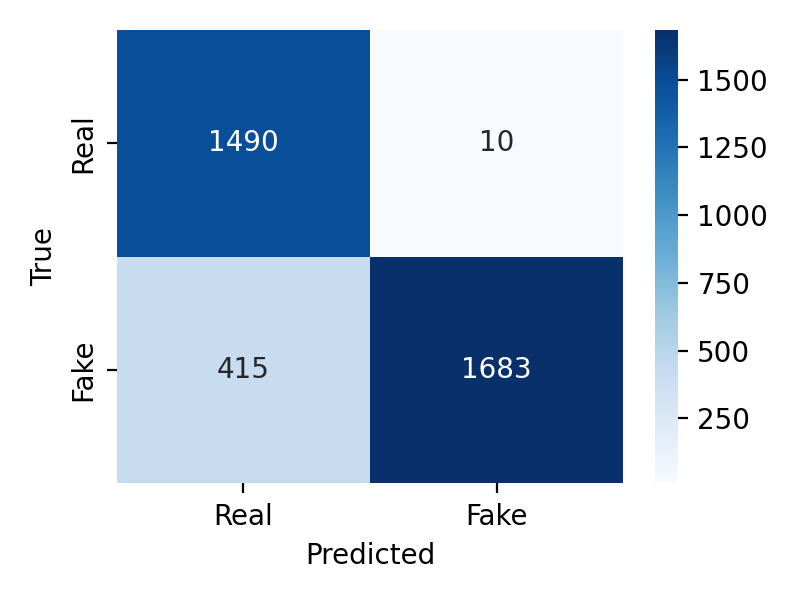

**R6 - roc_curve.png**

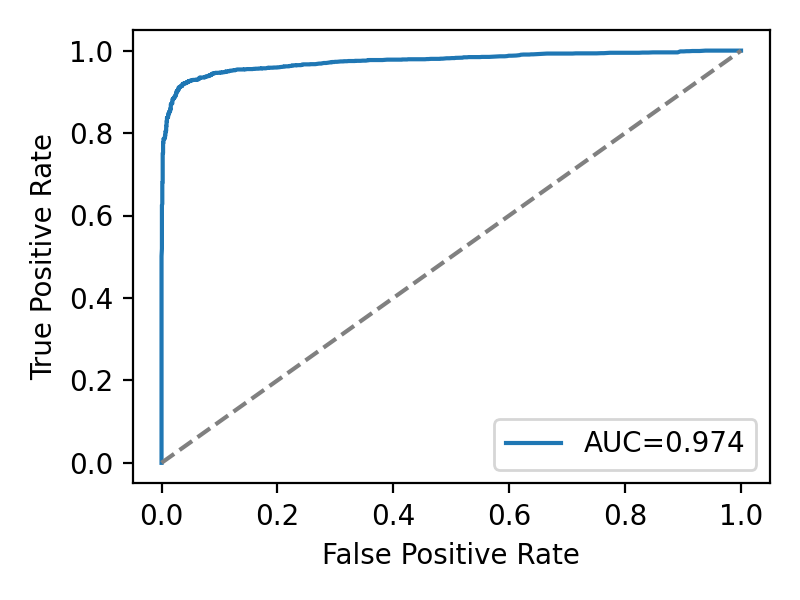

**R6 - history_loss.png**

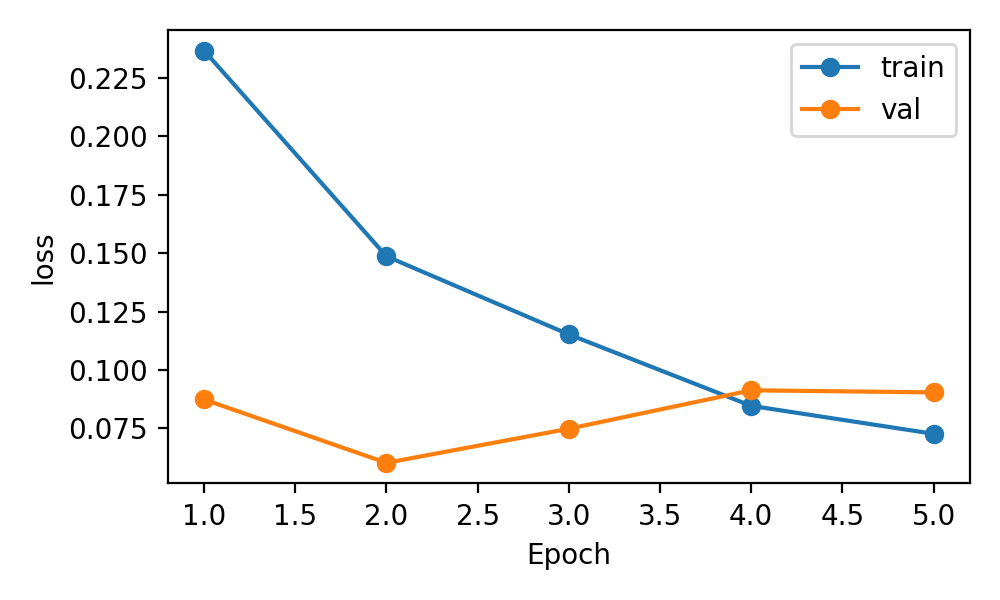

**R6 - history_auc.png**

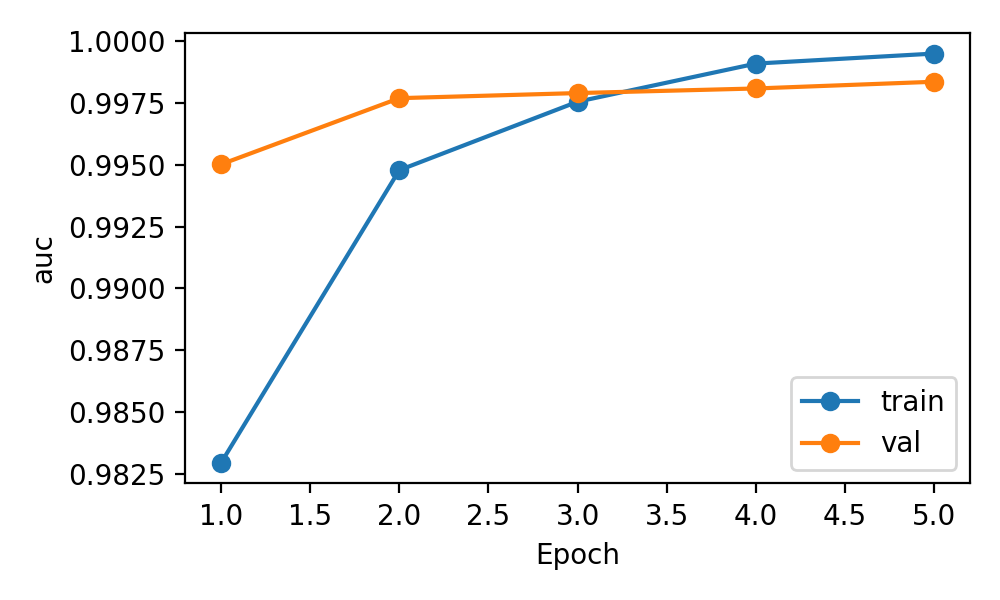

**R6 - history_acc.png**

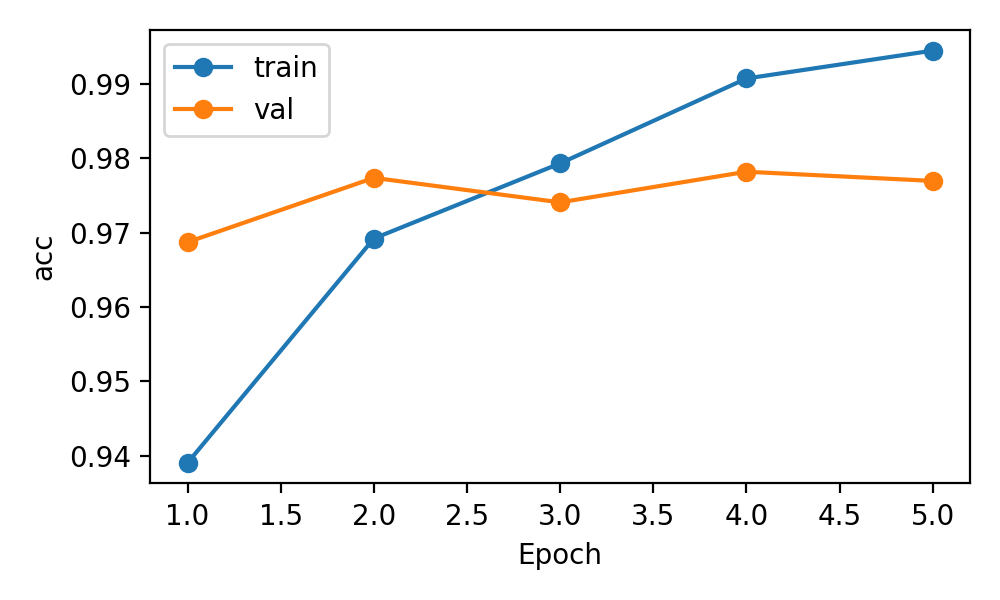

**R6 - history_f1.png**

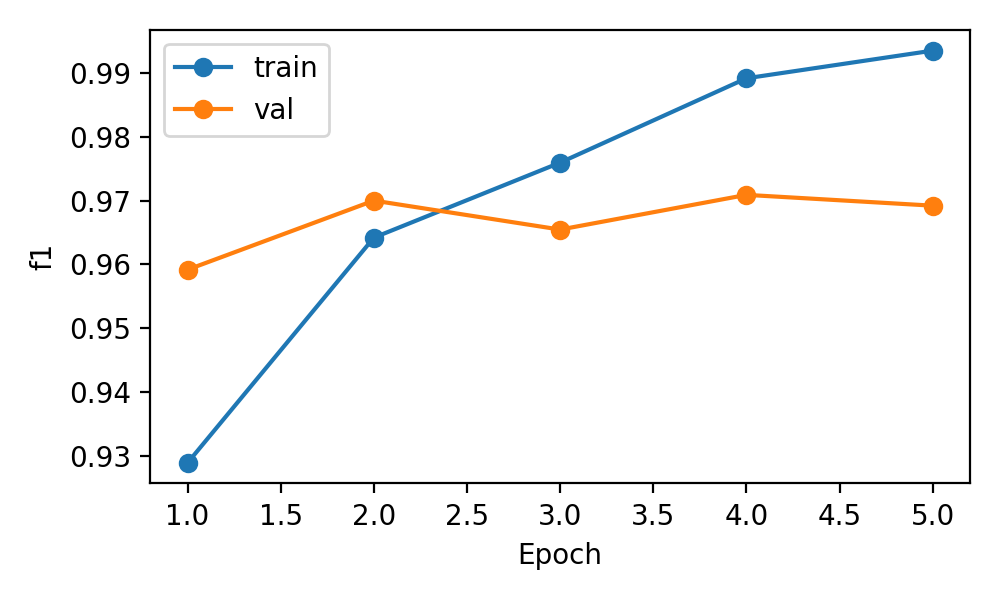

结果 Markdown 已更新：`docs/ood_split_experiment_results.md`

{'编号': 'R6',
 'Method': 'stf3_new_concat',
 'Spatial': '✓',
 'Temporal': '✓',
 'Frequency': '✓',
 'Fusion': 'Gated Concat',
 'Epochs': 5,
 'Best Val Epoch': 5,
 'Train Loss': 0.07264055192216833,
 'Train ACC': 0.9944593823840951,
 'Train AUC': 0.9994847741865569,
 'Val Loss': 0.09037713913232419,
 'Val ACC': 0.9769452449567724,
 'Val AUC': 0.9983466092572659,
 'Val F1': 0.9692307692307692,
 'Test ACC': 0.8818788215675375,
 'Test AUC': 0.9744037178265014,
 'Test F1': 0.8878923766816144,
 'Test Precision': 0.9940933254577673,
 'Test Recall': 0.8021925643469972,
 'TN': 1490,
 'FP': 10,
 'FN': 415,
 'TP': 1683,
 'Seconds Eval': 607.5487995147705,
 'Num Test Samples': 3598,
 'Run Dir': 'runs\\ood_stf3_new_concat',
 'Output Dir': 'outputs\\ood_stf3_new_concat',
 'Figure Dir': 'outputs\\figures\\ood_stf3_new_concat'}

In [9]:
# OOD-R6: stf3_new_concat
R6_summary = run_experiment("R6", force=False, poll_seconds=60, live_output=True)
R6_summary


### R7. STF3-New Final: `stf3_new`

运行下面 cell 开始 R7。默认 `force=False`，如需删除旧结果并重跑，改成 `force=True`。


========== R7: stf3_new ==========
run_dir = runs/ood_stf3_new
out_dir = outputs/ood_stf3_new
fig_dir = outputs/figures/ood_stf3_new

[start] R7 train
[log] logs/r7_stf3_new_train.log
[cmd] D:\VsCode Program\Python\content_security\final_project\.venv\Scripts\python.exe -m src.train --model stf3_new --train-csv data\GenVideo-Val\splits\ood_train.csv --val-csv data\GenVideo-Val\splits\ood_val.csv --epochs 5 --batch-size 1 --num-frames 8 --image-size 112 --foundation-backbone dinov2_vits14 --wavelet-aug-prob 0.1 --branch-dropout 0.1 --aux-loss-weight 0.2 --amp --out-dir runs\ood_stf3_new


```text
R7 train done, elapsed=229.9 min
eval: 100%|█████████▉| 2428/2429 [06:54<00:00,  9.71it/s]
```

[device] cuda
[model] stf3_new
Using cache found in C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
D:\VsCode Program\Python\content_security\final_project\src\models\fusion\branch_token_transformer.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
[params]

```text
R7 evaluate done, elapsed=10.5 min
predict: 100%|██████████| 3598/3598 [10:08<00:00,  5.91it/s]
```

Using cache found in C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\jacky/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
D:\VsCode Program\Python\content_security\final_project\src\models\fusion\branch_token_transformer.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
{'acc': 0.9160644802668149, 'auc': 0.96

```text
R7 visualize done, elapsed=0.1 min

```

[done] figures in outputs\figures\ood_stf3_new

[done] R7 visualize, elapsed=0.1 min
[write] docs/ood_split_experiment_results.md


,编号,Method,Spatial,Temporal,Frequency,Fusion,Epochs,Best Val Epoch,Val ACC,Val AUC,Val F1,Test ACC,Test AUC,Test F1,Test Precision,Test Recall
0,R5,spatial_temporal_new,✓,✓,,Transformer,5,3,0.978180,0.997536,0.971022,0.887715,0.979481,0.893852,0.995902,0.810772
1,R7,stf3_new,✓,✓,✓,Branch-token Transformer,5,3,0.974475,0.994897,0.966083,0.916064,0.965099,0.923506,0.985405,0.868923


**R7 - confusion_matrix.png**

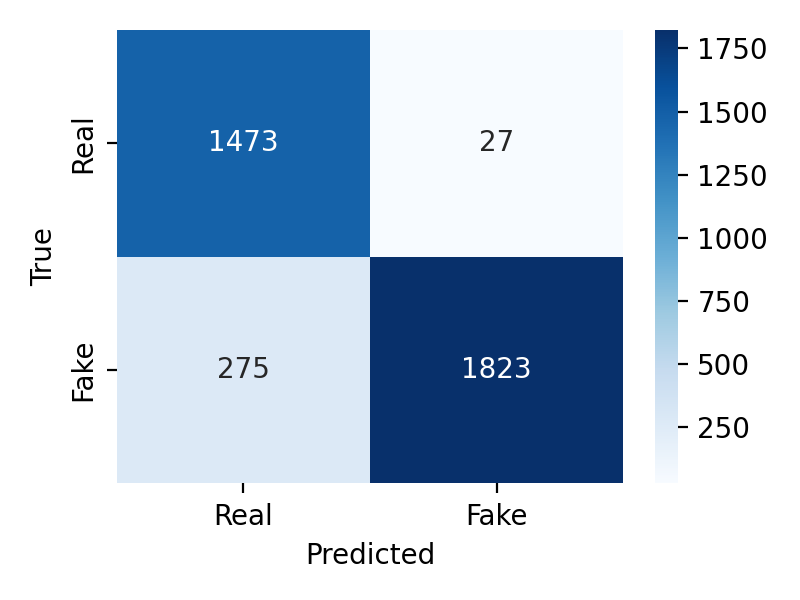

**R7 - roc_curve.png**

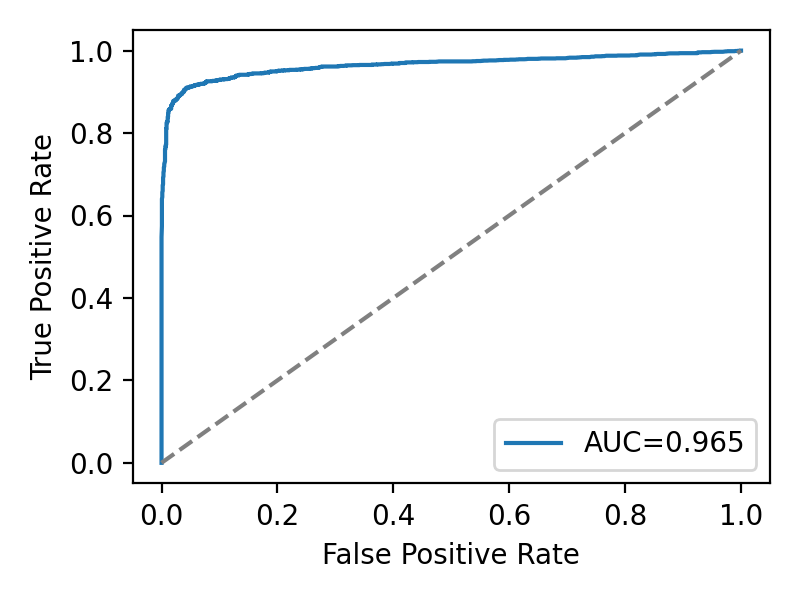

**R7 - history_loss.png**

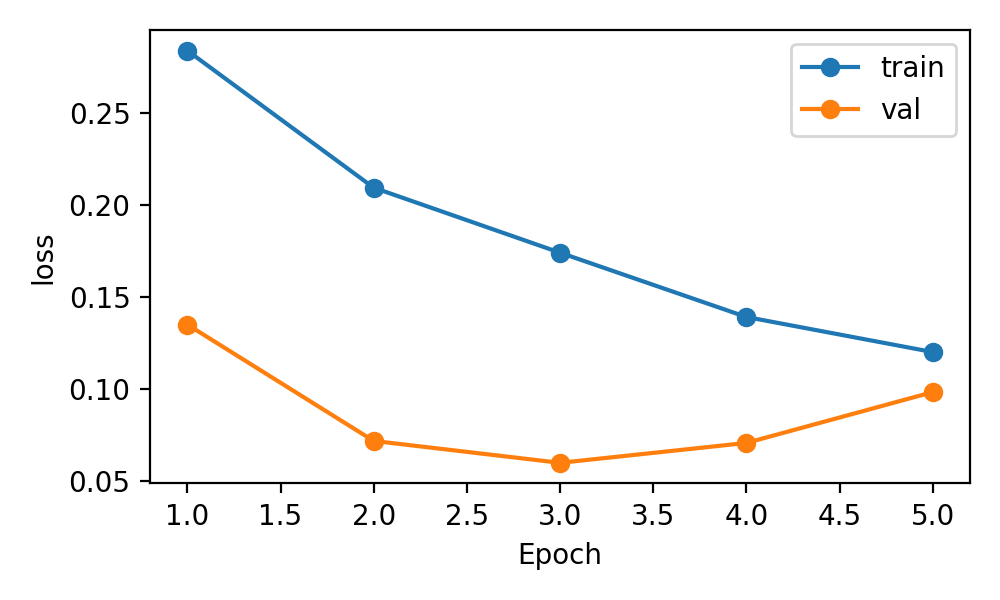

**R7 - history_auc.png**

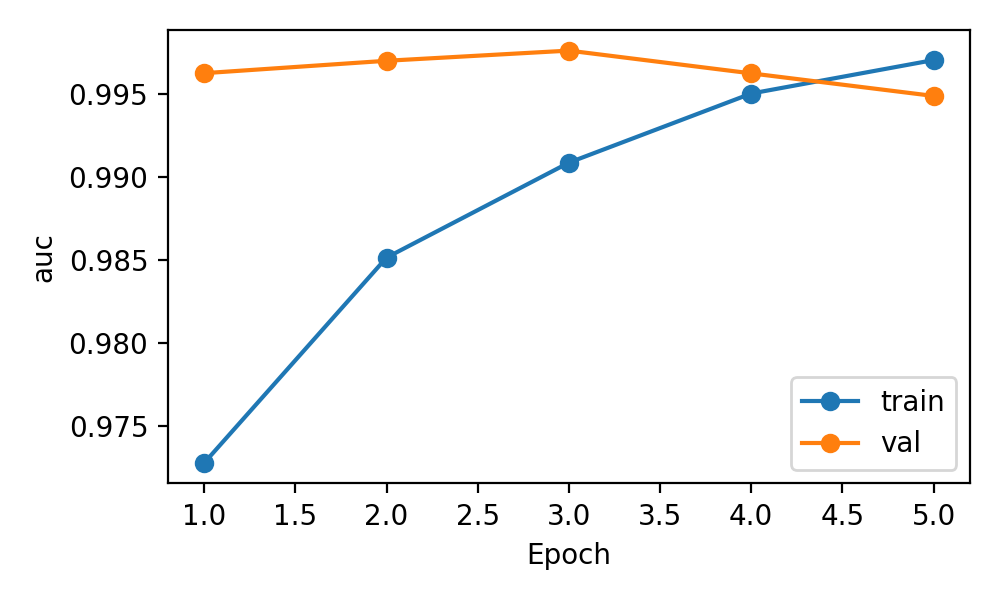

**R7 - history_acc.png**

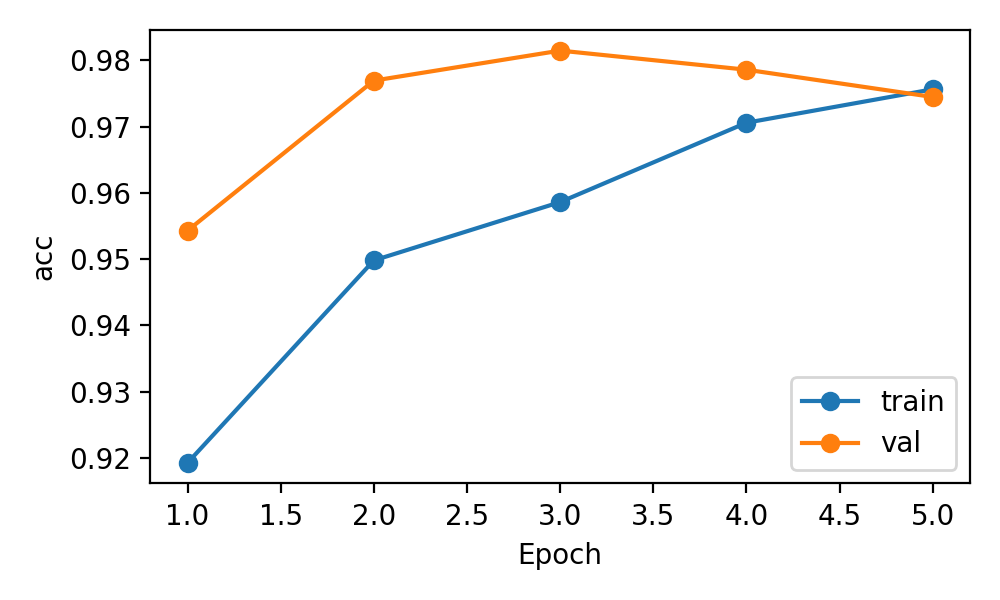

**R7 - history_f1.png**

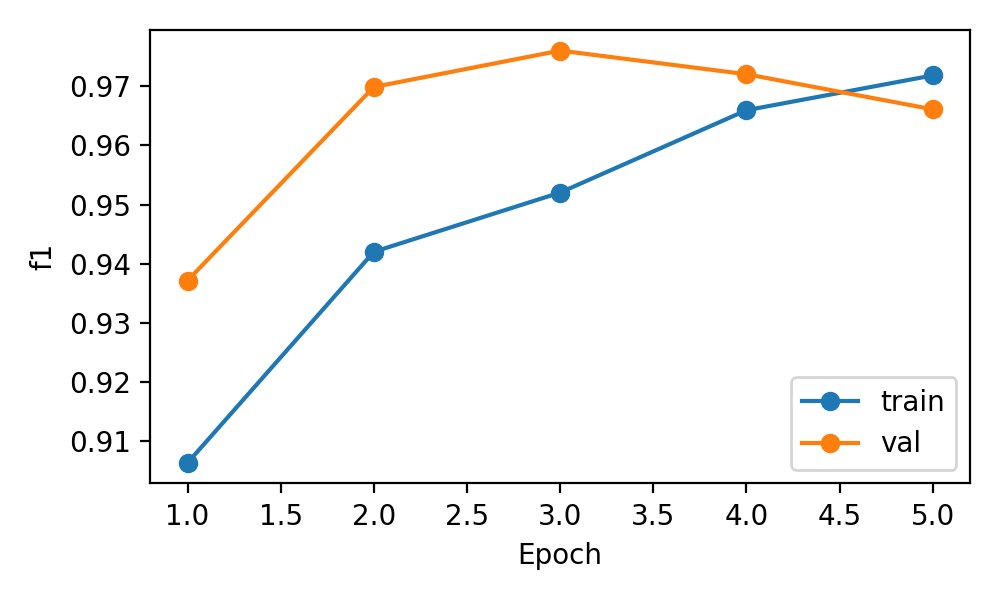

结果 Markdown 已更新：`docs/ood_split_experiment_results.md`

{'编号': 'R7',
 'Method': 'stf3_new',
 'Spatial': '✓',
 'Temporal': '✓',
 'Frequency': '✓',
 'Fusion': 'Branch-token Transformer',
 'Epochs': 5,
 'Best Val Epoch': 3,
 'Train Loss': 0.12014113286566303,
 'Train ACC': 0.9756375784241832,
 'Train AUC': 0.9970557557367722,
 'Val Loss': 0.09838126666656784,
 'Val ACC': 0.9744750926307122,
 'Val AUC': 0.994896663078579,
 'Val F1': 0.9660831509846827,
 'Test ACC': 0.9160644802668149,
 'Test AUC': 0.9650991420400381,
 'Test F1': 0.9235055724417427,
 'Test Precision': 0.9854054054054054,
 'Test Recall': 0.8689227836034319,
 'TN': 1473,
 'FP': 27,
 'FN': 275,
 'TP': 1823,
 'Seconds Eval': 608.883713722229,
 'Num Test Samples': 3598,
 'Run Dir': 'runs\\ood_stf3_new',
 'Output Dir': 'outputs\\ood_stf3_new',
 'Figure Dir': 'outputs\\figures\\ood_stf3_new'}

In [7]:
# OOD-R7: stf3_new
R7_summary = run_experiment("R7", force=False, poll_seconds=60, live_output=True)
R7_summary


## 8. 手动刷新总表和 Markdown

如果你移动了文件、补跑了评估，或者只想重新生成总表/Markdown，可以运行下面 cell。


In [ ]:
update_results_markdown()
df_all = display_current_summary()
df_all


## 9. 后续建议

Random R1-R7 都完成后，检查：

- `docs/ood_split_experiment_results.md`
- `runs/<split>_<model>/history.json`
- `outputs/<split>_<model>/metrics.json`
- `outputs/<split>_<model>/predictions.csv`
- `outputs/figures/<split>_<model>/*.png`

如果某个模型第 5 轮验证 AUC 仍在明显上升，再考虑按原方案补跑 10 epoch 精跑。
